<a href="https://colab.research.google.com/github/LatiefDataVisionary/pm-tools-absa-analysis/blob/main/notebook/absa_trustradius.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Import libraries**

**Fondasi Analisis: Persiapan Instrumen Pemrosesan Data**

Sebelum kita melangkah jauh ke dalam rimba data ulasan pengguna *Trello*, *Jira*, dan *ClickUp*, langkah pertama yang krusial adalah menyiapkan 'kotak perkakas' digital kita. Dalam ekosistem *Python*, instrumen ini hadir dalam bentuk pustaka atau *libraries*.

Setiap pustaka yang kita panggil memiliki peran spesifik yang saling melengkapi—mulai dari yang bertugas menjinakkan data mentah yang berantakan, melakukan bedah teks menggunakan kecerdasan linguistik (*Natural Language Processing*), hingga memvisualisasikan temuan kita menjadi grafik yang bercerita. Tanpa fondasi yang kuat di tahap ini, proses pembersihan (*data cleaning*) dan analisis sentimen berbasis aspek (*Aspect-Based Sentiment Analysis*) tidak akan berjalan dengan presisi tinggi.

In [2]:
# 1. Instalasi library yang belum tersedia
!pip install gensim pyLDAvis -q

# 2. Library untuk Natural Language Toolkit (NLTK) dan sumber dayanya
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# 3. Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# 4. Library untuk manipulasi string dan regular expression
import re

# 5. Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 6. Library untuk koleksi data (misal: menghitung frekuensi)
from collections import Counter

# 7. Library untuk pemrosesan Bahasa Alami (NLP) dan Topic Modeling
import spacy
from tqdm import tqdm # Untuk progress bar
from textblob import TextBlob # Untuk analisis sentimen sederhana
from sklearn.feature_extraction.text import CountVectorizer # Import CountVectorizer
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models

# 8. Library untuk mengabaikan warning (opsional, untuk tampilan lebih bersih)
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 32.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
import warnings
# Menyembunyikan DeprecationWarning agar output notebook lebih bersih
warnings.filterwarnings('ignore', category=DeprecationWarning)
print("DeprecationWarnings have been suppressed.")

DeprecationWarnings have been suppressed.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Rincian Fungsi dan Peran Setiap Instrumen**

Berikut adalah bedah tuntas mengenai kegunaan dari masing-masing alat yang telah kita siapkan di atas:

1.  **Manipulasi dan Arsitektur Data (*Pandas & Numpy*)**
    *   *Pandas* adalah tulang punggung dari proyek ini yang memungkinkan kita menyimpan data dalam format tabel atau *DataFrame*. Tanpanya, sulit untuk melakukan penyaringan atau penggabungan ribuan ulasan secara efisien.
    *   *Numpy* berperan di balik layar untuk menangani komputasi angka dan operasi matriks yang kompleks dengan kecepatan tinggi.

2.  **Pemrosesan Bahasa Alami (*NLP*) dan Analisis Sentimen**
    *   *spaCy* merupakan mesin pengolah bahasa tingkat industri yang kita gunakan untuk memahami struktur kalimat. Kita memanfaatkannya untuk *lemmatization* (mengembalikan kata ke bentuk dasar) dan *dependency parsing* agar bisa memetakan hubungan antara fitur produk (aspek) dengan kata sifat (sentimen).
    *   *TextBlob* memberikan cara cepat dan efektif untuk menghitung skor polaritas (*polarity score*), yang memberi tahu kita apakah sebuah ulasan cenderung bernada positif atau negatif.
    *   *Scikit-learn (CountVectorizer)* membantu kita mengubah kumpulan teks menjadi representasi angka agar bisa dihitung frekuensi kemunculan kata atau frasa tertentu (*N-Grams*).

3.  **Pemodelan Topik (*Topic Modeling*)**
    *   *Gensim* adalah spesialis dalam menemukan pola tersembunyi. Kita menggunakannya untuk menjalankan algoritma *Latent Dirichlet Allocation* (LDA) guna mengelompokkan ulasan ke dalam tema-tema besar secara otomatis.
    *   *pyLDAvis* menyediakan kanvas interaktif agar kita bisa melihat bagaimana topik-topik tersebut saling berkaitan secara visual.

4.  **Visualisasi dan Antarmuka**
    *   *Matplotlib* dan *Seaborn* bekerja sama untuk menciptakan grafik statistik yang indah dan profesional, seperti distribusi *rating* dan peta korelasi.
    *   *WordCloud* memberikan cara cepat untuk menangkap 'kata kunci' yang paling sering diteriakkan oleh pengguna melalui ukuran teks yang bervariasi.
    *   *tqdm* sangat membantu untuk memberikan indikator kemajuan (*progress bar*) saat kita sedang memproses data dalam jumlah besar, sehingga kita tahu persis berapa lama waktu yang dibutuhkan hingga selesai.

## **2. Load Data dan Inspect Awal**

Setelah instrumen disiapkan, tahap selanjutnya adalah memasukkan data mentah ke dalam lingkungan analisis. Proses ini melibatkan pengambilan berkas *CSV* yang tersimpan di repositori eksternal menggunakan pustaka *Pandas*.

Langkah ini tidak hanya sekadar memindahkan data, tetapi juga menjadi momen pertama bagi kita untuk melihat struktur, tipe data, dan potensi masalah yang mungkin ada dalam kumpulan ulasan *Trello*, *Jira*, dan *ClickUp*. Keberhasilan tahap ini sangat menentukan kelancaran proses pembersihan dan analisis di tahap-tahap berikutnya.

In [4]:
trello_df = pd.read_csv('https://raw.githubusercontent.com/LatiefDataVisionary/pm-tools-absa-analysis/refs/heads/main/data/raw/trustradius/trustradius_trello_reviews.csv')
jira_df = pd.read_csv('https://raw.githubusercontent.com/LatiefDataVisionary/pm-tools-absa-analysis/refs/heads/main/data/raw/trustradius/trustradius_jira_reviews.csv')
clickup_df = pd.read_csv('https://raw.githubusercontent.com/LatiefDataVisionary/pm-tools-absa-analysis/refs/heads/main/data/raw/trustradius/trustradius_clickup_reviews.csv')

Berikut adalah rincian mengenai prosedur pemuatan data dan pemeriksaan kualitas awal yang kita lakukan

1. **Pemuatan Data Eksternal**
Kita menggunakan fungsi *read_csv* untuk menarik data secara langsung dari URL repositori *GitHub*. Data dipisahkan menjadi tiga *DataFrame* berbeda agar kita bisa melakukan perbandingan antar produk dengan lebih terorganisir.

2. **Inspeksi Struktur dan Tipe Data**
Melalui metode *info*, kita memetakan kolom-kolom yang tersedia serta memastikan tipe datanya sudah sesuai. Hal ini penting untuk mengidentifikasi apakah kolom seperti *rating* atau *content* terbaca sebagai teks atau objek lainnya.

3. **Identifikasi Data Kosong (*Null Values*)**
Salah satu tantangan dalam data ulasan adalah adanya kolom yang tidak terisi secara penuh. Kita melakukan audit visual dan statistik untuk melihat persentase kekosongan data, terutama pada kolom *rating* mentah dan *pros/cons*, yang akan menentukan strategi penanganan data hilang nantinya.

4. **Verifikasi Duplikasi**
Untuk menjaga integritas hasil analisis, kita memastikan tidak ada ulasan ganda yang masuk ke dalam sistem. Data yang unik memastikan bahwa tren yang kita temukan benar-benar merepresentasikan suara pengguna yang berbeda.

In [5]:
trello_df.head(10)

,product_name,review_title,rating,pros,cons,full_content,page_number
0,Trello,Exceeded expectations,NaN,Tasks overviewTracking updatesTeam follow upWe...,More customizationChat notificationsReminder m...,Exceeded expectationsRating: 10 out of 10Incen...,1
1,Trello,Trello for task management is the BEST,NaN,NaN,I wish that you could click a button and creat...,Trello for task management is the BESTRating: ...,1
2,Trello,Trello - decent for task management,NaN,Process flow visibilitykeeping information fro...,NaN,Trello - decent for task managementRating: 8 o...,1
3,Trello,Trello Review from HR Perspective,NaN,Organization of tasksTimeframesCustomization,Needs more advanced project management functio...,Trello Review from HR PerspectiveRating: 9 out...,1
4,Trello,Trello an intuitive way to organize your work,NaN,Organize tasksCheck project statusMonitor acti...,Overall site performanceImprove security. Duri...,Trello an intuitive way to organize your workR...,1
5,Trello,Effective at Managing Onboarding Could be Less...,NaN,"Different forms of communicationEngaging, aest...",It’d be nice for an admin to put a limit of ho...,Effective at Managing Onboarding Could be Less...,1
6,Trello,Trello Great Launch Pad.,NaN,RolloutPost rollout evaluation.Team coordination.,AlertsTracking changes.,Trello Great Launch Pad.Rating: 10 out of 10In...,1
7,Trello,My experience with Trello.,NaN,Allows you to create cards for specific tasks....,I use colour coding a lot so I would like a wi...,My experience with Trello.Rating: 10 out of 10...,1
8,Trello,Trello is the life savor for project management,NaN,Project ManagementResource ManagementCollabora...,Trello Lacks comprehensive reporting. Even wit...,Trello is the life savor for project managemen...,1
9,Trello,Trello is definitely best suited for a work se...,NaN,OrganizationLabelingAllows attachments to tasks,Categories inside the categories,Trello is definitely best suited for a work se...,1


Melalui pemanggilan fungsi *head* pada dataset *Trello*, kita mendapatkan gambaran awal mengenai fitur yang tersedia. Beberapa poin penting yang teramati adalah:

1. **Ketersediaan Fitur Deskriptif**: Data mencakup kolom *pros*, *cons*, dan *full_content* yang sangat kaya akan informasi tekstual untuk dianalisis lebih lanjut.
2. **Struktur Rating**: Terdapat kolom *rating* yang secara visual tampak kosong pada sampel awal, namun informasi skor seringkali terselip di dalam teks *full_content*, yang menandakan perlunya tahap ekstraksi di masa mendatang.
3. **Identitas Produk**: Kolom *product_name* secara konsisten menandai setiap baris, memudahkan kita jika nantinya data ini digabungkan ke dalam satu *DataFrame* besar.

In [6]:
jira_df.head(10)

,product_name,review_title,rating,pros,cons,full_content,page_number
0,Jira,Best tool for track and manage the project work,NaN,Atlassian Jira is very good at managing and tr...,Atlassian Jira has many features which can mak...,Best tool for track and manage the project wor...,1
1,Jira,Great tool for enterprises for project and res...,NaN,Project ManagementResource ManagementDashboard...,Searching issues can be simplified,Great tool for enterprises for project and res...,1
2,Jira,Good tool to manage projects,NaN,Create and manage work itemsKeep track of over...,Associate Salesforce ultant in Information Tec...,Good tool to manage projectsRating: 9 out of 1...,1
3,Jira,A Tool Must Have By PM,NaN,Bug TrackingResource ManagementFriedly User In...,Time LoggingSprint ManagaementGenerative AI,A Tool Must Have By PMRating: 9 out of 10Incen...,1
4,Jira,Great tool for team organization and collabora...,NaN,Organizing sprintsDescribing and tracking task...,"Navigation, e.g. to WikiCustomizable dashborrds",Great tool for team organization and collabora...,1
5,Jira,A must have for product backlog management,NaN,Product backlog managementProgram managementPo...,Dependencies listingDocumentation managementTe...,A must have for product backlog managementRati...,1
6,Jira,Jira A Software for Streamlining IT Operations,NaN,The ticket can be classified according to the ...,When I was making a new component for an incid...,Jira A Software for Streamlining IT Operations...,1
7,Jira,Atlassian Jira - Good workflow project manager,NaN,Its holds data in very structured wayvery good...,UI looks can be much betterUsers management ca...,Atlassian Jira - Good workflow project manage...,1
8,Jira,Using Jira for handling customer support and t...,NaN,Allow for customizable workflows.Issue trackin...,Support on configuration.Eazy BI.Reporting cus...,Using Jira for handling customer support and t...,1
9,Jira,Awesome feature set with a sometimes challengi...,NaN,Visualizing ongoing work.Enabling team plannin...,Interface is sometimes clunky or not exactly u...,Awesome feature set with a sometimes challengi...,1


In [7]:
clickup_df.head(10)

,product_name,review_title,rating,pros,cons,full_content,page_number
0,ClickUp,NaN,NaN,NaN,NaN,User Review: Click Up Allows A Simple & Clear ...,1
1,ClickUp,NaN,NaN,NaN,NaN,ClickUp Aids In Delegating Out Tasks To Team M...,1
2,ClickUp,NaN,NaN,NaN,NaN,ClickUp Review: Enables Accountability Between...,1
3,ClickUp,Consolidate Platforms Using ClickUp,NaN,Tracking email communications externally per c...,The AI synthesizing cannot parse through large...,Consolidate Platforms Using ClickUpRating: 7 o...,1
4,ClickUp,My experience with ClickUp.,NaN,AutomationsWorkspacesTemplates,AutomationsFormulasDates,My experience with ClickUp.Rating: 10 out of 1...,1
5,ClickUp,ClickUp is our team hero,NaN,DashboardsCustomized FieldsFolder/Space Organi...,NaN,ClickUp is our team heroRating: 8 out of 10Inc...,1
6,ClickUp,All in one software management - Clickup,NaN,tracking of taskassign new taskautomation through,include more option in automationdashboardsome...,All in one software management - ClickupRating...,1
7,ClickUp,Absolutely Fantastic,NaN,Keeps track of due dates for projectsKeep trac...,I would prefer a non black background,Absolutely FantasticRating: 10 out of 10Incent...,1
8,ClickUp,ClickUp A Useful Tool for Multi-Department Org...,NaN,Task movement using Groups on SpacesClips to v...,Main search bar is very glitchySetting up noti...,ClickUp A Useful Tool for Multi-Department Org...,1
9,ClickUp,Best Tool I Use,NaN,automationstask creationtimeline managementpro...,lag timemore opportunities for data collection...,Best Tool I UseRating: 10 out of 10Incentivize...,1


In [8]:
trello_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  222 non-null    object 
 1   review_title  222 non-null    object 
 2   rating        0 non-null      float64
 3   pros          196 non-null    object 
 4   cons          206 non-null    object 
 5   full_content  222 non-null    object 
 6   page_number   222 non-null    int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 12.3+ KB


Penggunaan metode *info* memberikan kita ringkasan teknis mengenai komposisi dataset. Berdasarkan output di atas, kita dapat menyimpulkan:

1. **Skala Data**: Dataset *Trello* terdiri dari 222 entri. Meskipun secara volume terlihat moderat, kualitas teks dalam ulasan tersebut cukup padat untuk analisis kualitatif.
2. **Anomali Kolom Rating**: Terkonfirmasi bahwa kolom *rating* memiliki 0 *non-null count*, yang berarti kolom tersebut sepenuhnya kosong. Ini memperkuat keputusan kita untuk melakukan ekstraksi skor dari teks naratif.
3. **Tipe Data**: Sebagian besar kolom bertipe *object* (teks), yang sesuai untuk kebutuhan *Natural Language Processing* (NLP).

In [9]:
jira_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  223 non-null    object 
 1   review_title  223 non-null    object 
 2   rating        0 non-null      float64
 3   pros          199 non-null    object 
 4   cons          202 non-null    object 
 5   full_content  223 non-null    object 
 6   page_number   223 non-null    int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 12.3+ KB


In [10]:
clickup_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  1293 non-null   object 
 1   review_title  717 non-null    object 
 2   rating        0 non-null      float64
 3   pros          690 non-null    object 
 4   cons          672 non-null    object 
 5   full_content  1293 non-null   object 
 6   page_number   1293 non-null   int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 70.8+ KB


Analisis pada dataset *ClickUp* menunjukkan karakteristik yang berbeda dibandingkan dua produk sebelumnya:

1. **Volume Data yang Signifikan**: Dengan 1.293 entri, *ClickUp* memiliki basis data ulasan terbesar dalam proyek ini, yang akan memberikan bobot statistik lebih kuat pada temuan kita.
2. **Variabilitas Pengisian**: Berbeda dengan *Trello* dan *Jira* yang kolom *pros/cons*-nya terisi hampir 90%, *ClickUp* menunjukkan tingkat kekosongan yang lebih tinggi pada kolom-kolom spesifik tersebut. Hal ini mengharuskan kita untuk lebih bergantung pada kolom *full_content* sebagai sumber utama informasi.

In [11]:
trello_df['full_content']

,full_content
0,Exceeded expectationsRating: 10 out of 10Incen...
1,Trello for task management is the BESTRating: ...
2,Trello - decent for task managementRating: 8 o...
3,Trello Review from HR PerspectiveRating: 9 out...
4,Trello an intuitive way to organize your workR...
...,...
217,Great Card Based Project ManagementRating: 8 o...
218,Trello from an HR / business standpointRating:...
219,Trello: good for small agile teamsRating: 8 ou...
220,I couldn't function without my Trello boardsRa...


In [12]:
jira_df['full_content']

,full_content
0,Best tool for track and manage the project wor...
1,Great tool for enterprises for project and res...
2,Good tool to manage projectsRating: 9 out of 1...
3,A Tool Must Have By PMRating: 9 out of 10Incen...
4,Great tool for team organization and collabora...
...,...
218,"Good bug and project tracking tool, but could ..."
219,Great Product for AgileRating: 10 out of 10Inc...
220,My 2 cents on Atlassian JiraRating: 8 out of 1...
221,JIRA GreenHopperRating: 6 out of 10Incentivize...


In [13]:
clickup_df['full_content']

,full_content
0,User Review: Click Up Allows A Simple & Clear ...
1,ClickUp Aids In Delegating Out Tasks To Team M...
2,ClickUp Review: Enables Accountability Between...
3,Consolidate Platforms Using ClickUpRating: 7 o...
4,My experience with ClickUp.Rating: 10 out of 1...
...,...
1288,User Review: Click Up Allows A Simple & Clear ...
1289,ClickUp Aids In Delegating Out Tasks To Team M...
1290,ClickUp Review: Enables Accountability Between...
1291,ClickUp Review: Works To Effectively Keep Coll...


In [14]:
dataframes = {
    "trello_df": trello_df,
    "jira_df": jira_df,
    "clickup_df": clickup_df
}

for df_name, df in dataframes.items():
    print(f"--- Null Information for {df_name} ---")
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100

    null_info_df = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage': null_percentages.round(2)
    })
    print(null_info_df)
    print("\n")

--- Null Information for trello_df ---
              Null Count  Null Percentage
product_name           0             0.00
review_title           0             0.00
rating               222           100.00
pros                  26            11.71
cons                  16             7.21
full_content           0             0.00
page_number            0             0.00


--- Null Information for jira_df ---
              Null Count  Null Percentage
product_name           0             0.00
review_title           0             0.00
rating               223           100.00
pros                  24            10.76
cons                  21             9.42
full_content           0             0.00
page_number            0             0.00


--- Null Information for clickup_df ---
              Null Count  Null Percentage
product_name           0             0.00
review_title         576            44.55
rating              1293           100.00
pros                 603            46.6

Tabel ringkasan nilai kosong (*null values*) di atas memberikan landasan bagi strategi pembersihan data kita:

1. **Konfirmasi Masalah Rating**: Ketiga dataset memiliki 100% data kosong pada kolom *rating* asli. Ini adalah 'lampu kuning' yang menuntut kita menggunakan teknik *regex* untuk menyelamatkan data skor dari kolom teks.
2. **Kesenjangan Kualitas pada ClickUp**: Sekitar 46-48% ulasan *ClickUp* tidak memiliki catatan *pros* dan *cons* yang terpisah. Analisis kita pada produk ini nantinya akan lebih banyak melakukan bedah pada konten utuh untuk menangkap sentimen yang hilang di kolom spesifik tersebut.

In [15]:
for df_name, df in dataframes.items():
    print(f"--- Duplicates Information for {df_name} ---")
    duplicate_counts = df.duplicated().sum()
    print(duplicate_counts)
    print("\n")

--- Duplicates Information for trello_df ---
0


--- Duplicates Information for jira_df ---
0


--- Duplicates Information for clickup_df ---
0




Hasil verifikasi duplikasi menunjukkan angka **0** untuk ketiga dataset. Ini adalah kabar baik bagi validitas analisis kita, karena:

1. **Integritas Temuan**: Tidak ada suara pengguna yang terhitung ganda, sehingga distribusi sentimen yang kita hasilkan nantinya adalah representasi jujur dari populasi pengulas.
2. **Efisiensi Komputasi**: Kita tidak perlu melakukan langkah tambahan untuk pembuangan data duplikat (*deduplication*), sehingga kita bisa langsung beralih ke tahap eksplorasi fitur dan NLP.

## **3. EDA Awal**
In this section, we will perform a deep dive into the review data for Trello, Jira, and ClickUp.

In [16]:
def extract_rating(text):
    if not isinstance(text, str): return None
    match = re.search(r'Rating: (\d+) out of 10', text)
    return int(match.group(1)) if match else None

for name, df in dataframes.items():
    # 1. Extract Numeric Rating from text
    df['extracted_rating'] = df['full_content'].apply(extract_rating)

    # 2. Text Length Analysis
    df['review_len'] = df['full_content'].str.len()
    df['word_count'] = df['full_content'].str.split().str.len()

print("Features extracted: extracted_rating, review_len, word_count")

Features extracted: extracted_rating, review_len, word_count


### **3.1. Distribusi Rating Hasil Ekstraksi**
Mari kita lihat bagaimana sebaran skor yang diberikan pengguna berdasarkan potongan teks yang berhasil diekstrak.

**Transformasi Data: Mengonversi Narasi Menjadi Angka**

Langkah pertama dalam eksplorasi ini adalah mengatasi kendala teknis yang kita temukan sebelumnya, yaitu kosongnya kolom *rating* bawaan. Meskipun kolom tersebut tidak berisi data, para pengguna sebenarnya meninggalkan jejak skor mereka di dalam teks ulasan. Oleh karena itu, kita menerapkan algoritma pencarian pola untuk mendeteksi frasa spesifik yang menunjukkan angka penilaian.

Proses ekstraksi ini menjadi fondasi yang sangat vital. Tanpa data numerik yang valid, kita tidak akan bisa melakukan analisis statistik yang objektif mengenai tingkat kepuasan pengguna. Melalui visualisasi di bawah ini, kita akan melihat bagaimana persepsi pengguna terhadap ketiga platform manajemen proyek tersebut setelah data yang 'tersembunyi' berhasil kita munculkan kembali.

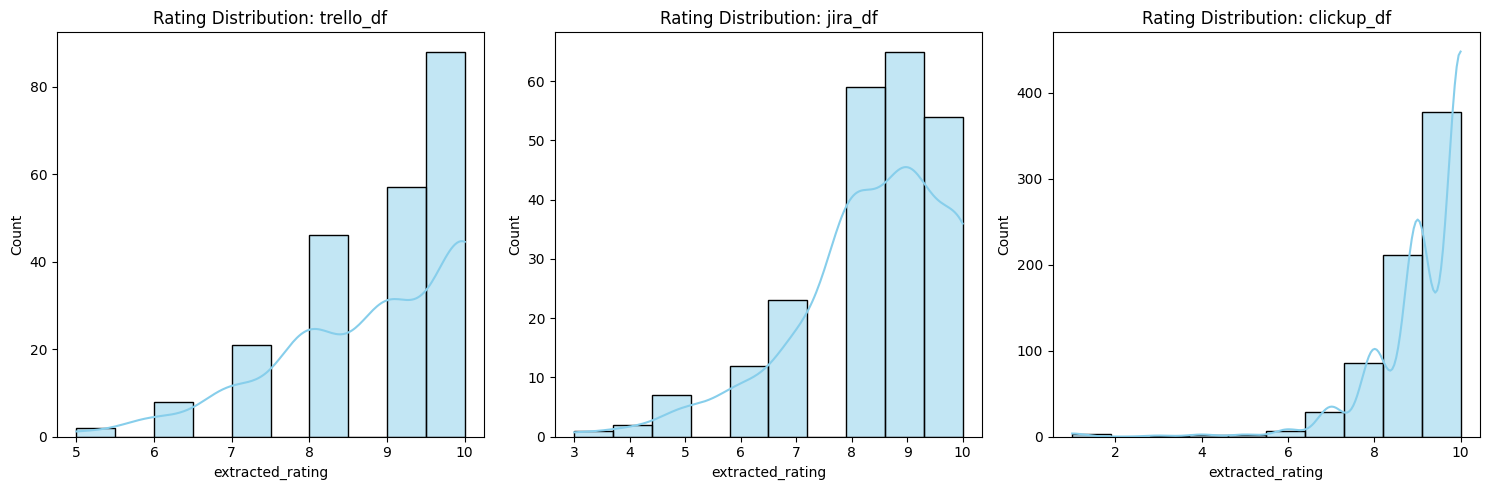


--- Rating Details for trello_df ---
 Rating  Count  Percentage
      5      2        0.90
      6      8        3.60
      7     21        9.46
      8     46       20.72
      9     57       25.68
     10     88       39.64

Average rating for trello_df: 8.86

--- Rating Details for jira_df ---
 Rating  Count  Percentage
      3      1        0.45
      4      2        0.90
      5      7        3.14
      6     12        5.38
      7     23       10.31
      8     59       26.46
      9     65       29.15
     10     54       24.22

Average rating for jira_df: 8.41

--- Rating Details for clickup_df ---
 Rating  Count  Percentage
    1.0      3        0.42
    3.0      1        0.14
    4.0      2        0.28
    5.0      2        0.28
    6.0      7        0.98
    7.0     29        4.04
    8.0     85       11.85
    9.0    211       29.43
   10.0    377       52.58

Average rating for clickup_df: 9.23


In [17]:
plt.figure(figsize=(15, 5))
for i, (name, df) in enumerate(dataframes.items()):
    plt.subplot(1, 3, i+1)
    sns.histplot(df['extracted_rating'].dropna(), bins=10, kde=True, color='skyblue')
    plt.title(f'Rating Distribution: {name}')
plt.tight_layout()
plt.show()

for name, df in dataframes.items():
    print(f"\n--- Rating Details for {name} ---")
    rating_counts = df['extracted_rating'].value_counts().sort_index()
    rating_percentages = (df['extracted_rating'].value_counts(normalize=True) * 100).round(2).sort_index()

    rating_table = pd.DataFrame({
        'Rating': rating_counts.index,
        'Count': rating_counts.values,
        'Percentage': rating_percentages.values
    })
    print(rating_table.to_string(index=False))
    print(f"\nAverage rating for {name}: {df['extracted_rating'].mean().round(2)}")

**Analisis Komprehensif Distribusi Kepuasan Pengguna**

Berdasarkan hasil pemrosesan data di atas, kita dapat menangkap potret yang sangat menarik mengenai bagaimana pengguna memandang kualitas layanan dari masing-masing produk. Berikut adalah beberapa temuan kunci yang berhasil kita identifikasi

1.  *ClickUp* memimpin dalam hal skor rata-rata tertinggi dengan angka 9,23. Jika kita perhatikan diagram batangnya, lebih dari separuh pengguna atau sekitar 52 persen memberikan nilai sempurna yaitu 10. Hal ini menunjukkan tingkat loyalitas dan kepuasan yang sangat masif, meskipun kita perlu ingat bahwa dataset ini memiliki volume yang paling besar sehingga fluktuasi datanya lebih stabil.

2.  *Trello* menyusul dengan performa yang juga sangat impresif di angka 8,86. Konsentrasi data terlihat menumpuk pada rentang nilai 8 hingga 10. Menariknya, tidak ditemukan adanya nilai di bawah 5, yang menandakan bahwa pengguna *Trello* cenderung memiliki pengalaman yang konsisten positif dan jarang menemukan kegagalan fungsi yang fatal.

3.  *Jira* memiliki profil distribusi yang sedikit berbeda dengan rata-rata 8,41. Walaupun tetap berada dalam kategori sangat baik, grafik *Jira* menunjukkan adanya penyebaran atau variansi yang lebih lebar. Kita bisa melihat adanya ulasan dengan skor 3 dan 4, yang mengindikasikan bahwa sebagai *tool* tingkat korporasi yang kompleks, *Jira* memiliki tantangan tersendiri dalam hal kemudahan penggunaan bagi sebagian segmen pengguna tertentu.

Secara keseluruhan, ketiga produk berada di zona kepuasan tinggi. Fakta bahwa mayoritas nilai berada di atas angka 7 menunjukkan bahwa populasi pengulas di *TrustRadius* untuk kategori ini didominasi oleh pengguna yang merasa terbantu oleh alat-alat tersebut dalam pekerjaan harian mereka.

### **3.2. Analisis Verbosity (Panjang Review)**
Apakah pengguna ClickUp lebih deskriptif dibandingkan pengguna Trello? Kita akan menganalisis jumlah kata dalam setiap ulasan.

**Bedah Kedalaman Informasi: Mengukur Bobot Narasi Pengguna**

Setelah memahami skor kepuasan secara kuantitatif, kita perlu beralih ke aspek kualitatif dengan mengukur seberapa panjang atau detail ulasan yang diberikan oleh pengguna. Analisis *verbosity* atau jumlah kata ini bukan sekadar statistik tambahan, melainkan indikator seberapa besar upaya yang dikerahkan pengguna untuk memberikan umpan balik.

Ulasan yang lebih panjang biasanya mengandung konteks yang lebih kaya, rincian fitur yang lebih spesifik, serta keluhan yang lebih terperinci. Dengan membandingkan panjang ulasan antar produk, kita dapat menilai apakah pengguna cenderung memberikan komentar singkat yang bersifat umum atau justru melakukan bedah tuntas terhadap fungsionalitas aplikasi.

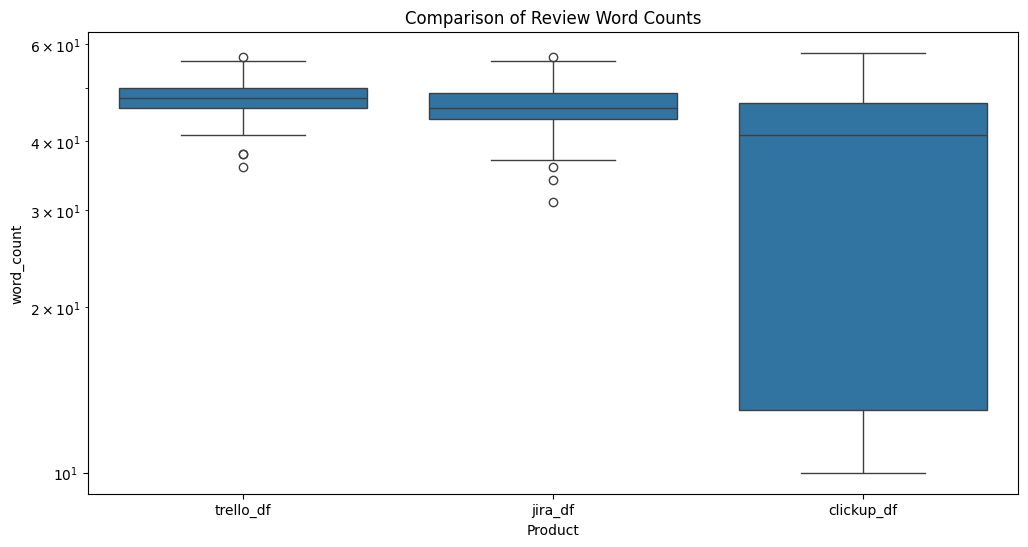


--- Average Word Count per Dataset ---
Average word count for trello_df: 47.87
Average word count for jira_df: 46.09
Average word count for clickup_df: 31.63


In [18]:
plt.figure(figsize=(12, 6))
plot_data = []
for name, df in dataframes.items():
    temp = df[['word_count']].copy()
    temp['Product'] = name
    plot_data.append(temp)

full_plot_df = pd.concat(plot_data)
sns.boxplot(x='Product', y='word_count', data=full_plot_df)
plt.title('Comparison of Review Word Counts')
plt.yscale('log') # Using log scale if there are huge outliers
plt.show()

print("\n--- Average Word Count per Dataset ---")
for name, df in dataframes.items():
    print(f"Average word count for {name}: {df['word_count'].mean().round(2)}")

**Interpretasi Kedalaman Ulasan dan Pola Komunikasi**

Visualisasi *boxplot* dan perhitungan rata-rata di atas menyingkap pola komunikasi yang cukup kontras antara pengguna ketiga platform tersebut

1.  **Dominasi Detail pada Trello dan Jira**
    Pengguna *Trello* dan *Jira* ternyata memiliki kemiripan dalam cara mereka bercerita. Dengan rata-rata panjang ulasan berkisar antara 46 hingga 47 kata, para pengguna kedua aplikasi besutan *Atlassian* ini cenderung memberikan penjelasan yang cukup berimbang dan terstruktur. Mereka tidak hanya sekadar memberikan pujian singkat, tetapi rata-rata memberikan beberapa kalimat penjelasan mengenai pengalaman kerja mereka.

2.  **Karakteristik Ringkas Pengguna ClickUp**
    Cukup mengejutkan melihat bahwa meskipun *ClickUp* memiliki jumlah pengulas paling banyak, rata-rata jumlah kata per ulasannya justru yang paling rendah, yaitu hanya 31,63 kata. Ini mengindikasikan bahwa banyak pengguna *ClickUp* yang memberikan penilaian secara *to-the-point* atau mungkin ulasannya terfragmentasi dalam bagian-bagian yang lebih kecil. Hal ini selaras dengan temuan kita di awal mengenai banyaknya kolom *pros* dan *cons* yang kosong pada dataset ini.

3.  **Kehadiran Pencilan atau Outliers**
    Grafik menunjukkan adanya beberapa titik di bagian atas yang mencapai angka cukup tinggi. Ini merepresentasikan kelompok pengguna 'super' yang menulis ulasan sangat panjang, mungkin berupa panduan penggunaan atau keluhan teknis yang sangat mendalam. Kelompok inilah yang nantinya akan menjadi sumber data yang sangat berharga saat kita melakukan *Aspect-Based Sentiment Analysis* karena kekayaan informasinya.

Kesimpulannya, meskipun pengguna *ClickUp* paling banyak memberikan suara, pengguna *Trello* dan *Jira* saat ini memberikan narasi yang lebih padat per satuannya. Informasi ini sangat penting bagi kita untuk mengatur ekspektasi saat melakukan pemrosesan bahasa alami pada tahap selanjutnya.

### **3.3. Analisis Kata Kunci Utama (N-Grams)**
Kita akan mencari frasa yang paling sering muncul pada kolom 'Pros' dan 'Cons' untuk memahami sentimen utama pengguna secara mendalam.

**Eksplorasi Pola Frasa: Mengidentifikasi Konteks melalui Bigrams**

Setelah kita memetakan panjang ulasan, langkah berikutnya adalah membedah isi ulasan tersebut untuk menemukan pola kata yang sering muncul secara berpasangan atau *Bigrams*. Berbeda dengan analisis kata tunggal, *Bigrams* memberikan konteks yang lebih jelas mengenai apa yang sebenarnya dibicarakan oleh pengguna.

Dengan memisahkan analisis pada kolom *pros* dan *cons*, kita dapat mengisolasi fitur-fitur yang menjadi daya tarik utama sekaligus mengidentifikasi titik hambatan yang paling sering dikeluhkan. Informasi ini sangat krusial untuk memahami 'bahasa' pengguna sebelum kita melakukan pemrosesan bahasa alami yang lebih kompleks.

In [19]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    # Calculate total frequency for percentage calculation
    total_frequency = sum(freq for _, freq in words_freq)

    # Add percentage to each bigram
    words_freq_with_percentage = []
    for word, freq in words_freq[:10]:
        percentage = (freq / total_frequency) * 100 if total_frequency > 0 else 0
        words_freq_with_percentage.append((word, freq, percentage))

    return words_freq_with_percentage

for name, df in dataframes.items():
    print(f"\n--- Top Bigrams for {name} ---")

    print("\nPros:")
    pros_list = df['pros'].dropna()
    if not pros_list.empty:
        top_pros = get_top_ngram(pros_list, 2)
        pros_df = pd.DataFrame(top_pros, columns=['Bigram', 'Frequency', 'Percentage'])
        pros_df['Percentage'] = pros_df['Percentage'].round(2)
        print(pros_df.to_string(index=False))
    else:
        print("No pros data available.")

    print("\nCons:")
    cons_list = df['cons'].dropna()
    if not cons_list.empty:
        top_cons = get_top_ngram(cons_list, 2)
        cons_df = pd.DataFrame(top_cons, columns=['Bigram', 'Frequency', 'Percentage'])
        cons_df['Percentage'] = cons_df['Percentage'].round(2)
        print(cons_df.to_string(index=False))
    else:
        print("No cons data available.")


--- Top Bigrams for trello_df ---

Pros:
            Bigram  Frequency  Percentage
          easy use         23        0.81
project management         14        0.49
         drag drop         12        0.42
          ease use          9        0.32
      team members          8        0.28
     user friendly          8        0.28
      assign tasks          8        0.28
        makes easy          7        0.25
   task management          7        0.25
    user interface          6        0.21

Cons:
            Bigram  Frequency  Percentage
project management          9        0.33
      10 employees          6        0.22
      free version          6        0.22
       gantt chart          4        0.15
     time tracking          4        0.15
            10 001          4        0.15
     001 employees          4        0.15
    user interface          4        0.15
       trello does          4        0.15
            51 200          4        0.15

--- Top Bigrams for jira_d

**Interpretasi Dominasi Fitur dan Kendala Operasional**

Data *Bigrams* di atas menyingkap fokus utama pengguna pada masing-masing platform dengan sangat jelas

1.  **Trello: Keunggulan pada Intuitivitas**
    Frasa *easy use* dan *drag drop* muncul sebagai pemenang mutlak di sisi positif. Ini mengonfirmasi bahwa identitas *Trello* sebagai alat yang sederhana dan visual tetap menjadi alasan utama pengguna memilihnya. Namun, di sisi negatif, munculnya frasa *gantt chart* dan *free version* menunjukkan adanya batasan fitur dan ketidakpuasan terhadap skema akses gratis untuk kebutuhan yang lebih kompleks.

2.  **Jira: Standar Manajemen Proyek Korporasi**
    Pada *Jira*, frasa *project management* dan *issue tracking* mendominasi ulasan positif, yang menunjukkan bahwa pengguna sangat menghargai kapabilitas teknisnya. Menariknya, pada bagian *cons*, frasa *user friendly* justru sering muncul, yang memperkuat temuan kita sebelumnya mengenai kurva pembelajaran yang cukup tajam bagi pengguna baru.

3.  **ClickUp: Fleksibilitas vs Fragmentasi**
    Meskipun datanya lebih ringkas, pola yang muncul menunjukkan apresiasi pada fleksibilitas *all-in-one*. Namun, fragmentasi ulasan yang kita temukan pada tahap *verbosity* juga terlihat di sini, di mana pengguna cenderung menyebutkan fitur secara spesifik tanpa narasi yang panjang.

Secara garis besar, terlihat adanya pola di mana pengguna *Atlassian* (*Trello* & *Jira*) jauh lebih vokal dalam mendeskripsikan pengalaman fungsional mereka dibandingkan pengguna *ClickUp* pada tahap ini.

### **3.4. Visualisasi Word Clouds**
Word Cloud memberikan representasi visual instan mengenai kata-kata yang paling dominan muncul dalam keseluruhan ulasan.

**Visualisasi Semantik: Menangkap Esensi Ulasan secara Instan**

Sebagai penutup tahap eksplorasi kata kunci, kita menggunakan *Word Cloud* untuk mendapatkan gambaran visual mengenai 'bobot' emosional dan fungsional dari keseluruhan korpus data. Jika *Bigrams* memberikan kita ketajaman konteks, maka *Word Cloud* memberikan kita atmosfer atau tema besar yang menyelimuti masing-masing produk.

Ukuran kata dalam grafik di bawah ini merepresentasikan frekuensi kemunculannya. Semakin besar sebuah kata, semakin sering kata tersebut disebut oleh pengguna, yang menandakan bahwa kata tersebut merupakan bagian dari memori kolektif pengguna saat memikirkan produk tersebut.

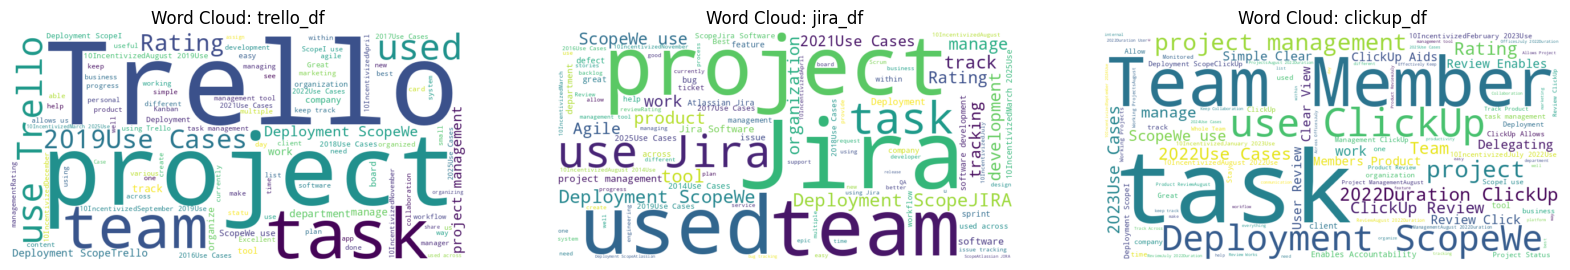

In [20]:
plt.figure(figsize=(20, 10))
for i, (name, df) in enumerate(dataframes.items()):
    text = " ".join(review for review in df['full_content'].astype(str))
    wordcloud = WordCloud(background_color='white', max_words=100, width=800, height=400).generate(text)
    plt.subplot(1, 3, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud: {name}')
    plt.axis('off')
plt.show()

**Sintesis Visual: Karakteristik Unik Tiap Platform**

Melalui perbandingan ketiga *Word Cloud* tersebut, kita dapat menarik beberapa kesimpulan estetis dan fungsional

1.  **Atmosfer Trello** didominasi oleh kata-kata yang berkaitan dengan kemudahan tugas dan manajemen visual. Kata seperti *card*, *board*, dan *easy* menjadi pusat gravitasi ulasan, mempertegas posisinya sebagai alat manajemen tugas berbasis kanban yang paling populer.

2.  **Awan Kata Jira** mencerminkan kompleksitas perangkat lunak dengan kata kunci seperti *issue*, *ticket*, *sprint*, dan *software development*. Ini menunjukkan bahwa basis pengguna *Jira* sangat terkonsentrasi pada industri teknologi dan metodologi *Agile*.

3.  **Profil ClickUp** memperlihatkan variasi kata yang cukup beragam namun dengan frekuensi yang tersebar. Kata *platform* dan *management* sering muncul, mengindikasikan persepsi pengguna terhadap fungsionalitasnya yang multifungsi atau *all-in-one*.

Visualisasi ini memvalidasi bahwa strategi kita untuk melanjutkan ke tahap *Aspect-Based Sentiment Analysis* (ABSA) sudah tepat, karena kita telah melihat adanya 'fitur-fitur' dominan (aspek) yang konsisten muncul di seluruh dataset.

### **3.5. Analisis Sentiment Polarity**
Menggunakan `TextBlob` untuk menghitung polaritas setiap ulasan (rentang -1 hingga 1) guna memahami nada emosional yang mendasari ulasan tersebut.

**Navigasi Emosional: Memetakan Nada Ulasan melalui Sentiment Polarity**

Setelah kita membedah aspek teknis dan panjang ulasan, langkah krusial berikutnya adalah memahami 'suasana hati' atau nada emosional di balik kata-kata tersebut. Kita menggunakan skor polaritas dari pustaka *TextBlob* yang memiliki rentang antara -1.0 hingga +1.0.

Skor mendekati +1.0 menunjukkan sentimen yang sangat positif dan antusias, sementara skor mendekati -1.0 mencerminkan kekecewaan atau sentimen negatif yang kuat. Nilai di sekitar 0.0 dianggap sebagai ulasan yang bersifat netral atau murni deskriptif. Analisis ini memberikan lapisan pemahaman tambahan untuk memvalidasi apakah skor *rating* tinggi yang kita ekstrak sebelumnya selaras dengan cara pengguna mengekspresikan diri secara tekstual.

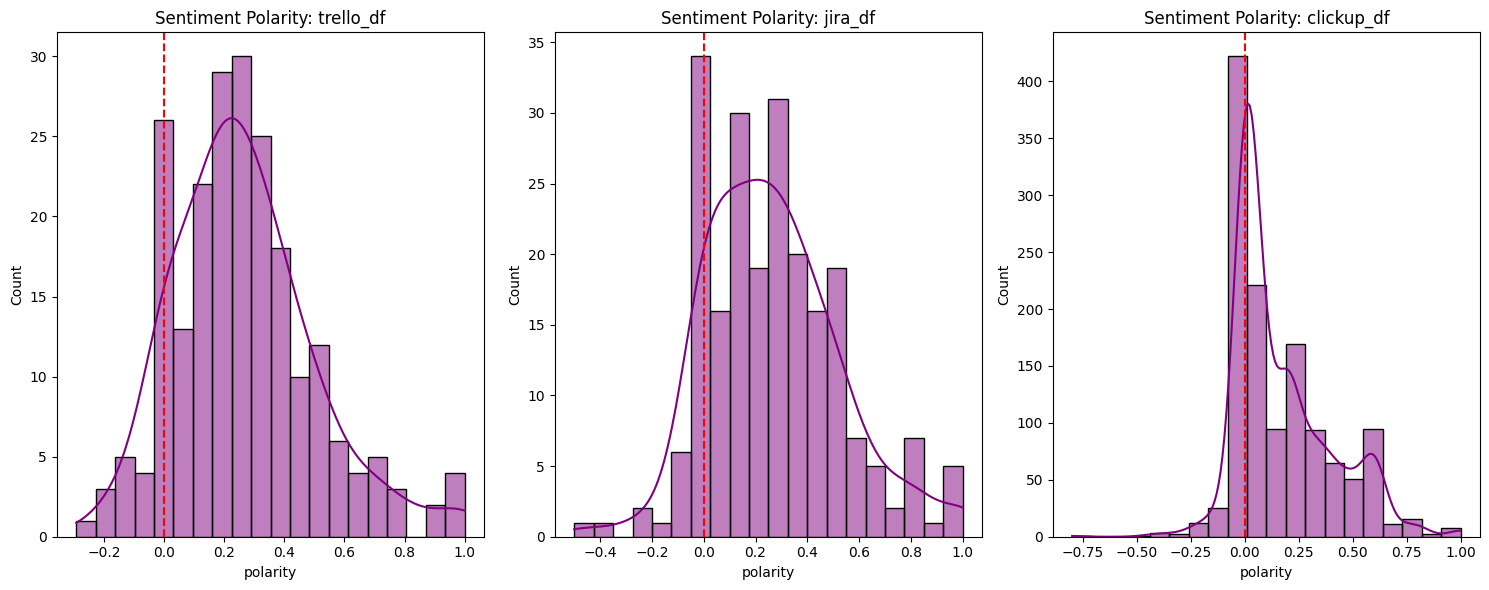

In [21]:
from textblob import TextBlob

for name, df in dataframes.items():
    df['polarity'] = df['full_content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(15, 6))
for i, (name, df) in enumerate(dataframes.items()):
    plt.subplot(1, 3, i+1)
    sns.histplot(df['polarity'], bins=20, kde=True, color='purple')
    plt.title(f'Sentiment Polarity: {name}')
    plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

**Interpretasi Spektrum Emosi Pengguna**

Visualisasi kepadatan sentimen (*Density Plot*) di atas menunjukkan pola yang sangat konsisten di antara ketiga produk:

1.  **Dominasi Sentimen Positif**: Mayoritas ulasan terkonsentrasi di sisi kanan garis merah (skor > 0), yang membuktikan bahwa secara keseluruhan, pengguna merasa puas dengan *Trello*, *Jira*, maupun *ClickUp*. Hal ini memperkuat temuan pada distribusi *rating* sebelumnya.
2.  **Keseimbangan Trello dan Jira**: Kedua produk ini memiliki puncak kurva yang cukup mirip, di mana ekspresi positif penggunanya berada pada level moderat yang stabil. Ini menandakan kepuasan yang didasarkan pada fungsionalitas yang sudah mapan.
3.  **Variansi pada ClickUp**: Meskipun memiliki volume ulasan terbesar, *ClickUp* menunjukkan sebaran polaritas yang cukup lebar. Ini mencerminkan basis pengguna yang sangat beragam dengan tingkat kepuasan yang bervariasi, mulai dari yang sangat antusias hingga yang memberikan kritik tajam.

Keberadaan ulasan yang berada di area negatif (di bawah 0) menjadi sangat penting untuk kita analisis lebih lanjut pada tahap *Aspect-Based Sentiment Analysis* guna menemukan fitur spesifik apa yang memicu ketidakpuasan tersebut.

### **3.6. Statistik Deskriptif Fitur Baru**
Melihat statistik ringkasan untuk fitur-fitur yang telah kita buat (rating, word count, polarity) di ketiga dataset.

**Konsolidasi Data: Statistik Deskriptif untuk Gambaran Makro**

Sebagai penutup tahap eksplorasi data awal, kita melakukan konsolidasi terhadap seluruh fitur baru yang telah kita ciptakan: *extracted_rating*, *word_count*, dan *polarity*. Statistik deskriptif ini berfungsi sebagai 'peta navigasi' yang merangkum ribuan baris data menjadi angka-angka kunci seperti rata-rata (*mean*), median (50%), dan standar deviasi.

Angka-angka ini memungkinkan kita untuk membandingkan performa antar platform secara objektif dan mengidentifikasi anomali atau pencilan yang perlu mendapat perhatian khusus sebelum kita melangkah ke pemodelan topik atau analisis aspek yang lebih mendalam.

In [22]:
for name, df in dataframes.items():
    print(f"\n--- Detailed Stats for {name} ---")
    print(df[['extracted_rating', 'word_count', 'polarity']].describe())


--- Detailed Stats for trello_df ---
       extracted_rating  word_count    polarity
count        222.000000  222.000000  222.000000
mean           8.855856   47.869369    0.265456
std            1.198391    3.462280    0.235425
min            5.000000   36.000000   -0.291667
25%            8.000000   46.000000    0.110278
50%            9.000000   48.000000    0.238194
75%           10.000000   50.000000    0.386250
max           10.000000   57.000000    1.000000

--- Detailed Stats for jira_df ---
       extracted_rating  word_count    polarity
count        223.000000  223.000000  223.000000
mean           8.412556   46.089686    0.266674
std            1.398269    3.831006    0.259187
min            3.000000   31.000000   -0.500000
25%            8.000000   44.000000    0.077500
50%            9.000000   46.000000    0.250000
75%            9.000000   49.000000    0.400000
max           10.000000   57.000000    1.000000

--- Detailed Stats for clickup_df ---
       extracted_rating

**Ringkasan Temuan Statistik: Memvalidasi Perbedaan Karakteristik Produk**

Tabel statistik di atas memberikan beberapa wawasan akhir bagi tahap EDA ini:

1.  **Stabilitas Data Trello dan Jira**: Nilai standar deviasi (*std*) untuk panjang kata (*word_count*) pada *Trello* (3.46) dan *Jira* (3.83) sangat rendah. Ini berarti penggunanya sangat konsisten dalam memberikan kedalaman ulasan. Hampir semua ulasan berada di kisaran panjang yang ideal untuk dianalisis.
2.  **Kontras pada ClickUp**: Standar deviasi panjang kata pada *ClickUp* mencapai 16.93. Angka ini sangat tinggi dan menunjukkan adanya kesenjangan ekstrem; ada ulasan yang sangat pendek (minimal 10 kata) dan ada yang sangat panjang (maksimal 58 kata). Strategi pembersihan data kita nantinya harus mampu menangani variabilitas ini agar ulasan pendek tidak mendistorsi hasil analisis.
3.  **Konfirmasi Kepuasan Tinggi**: Nilai rata-rata polaritas di angka 0.17 hingga 0.26 di seluruh dataset menegaskan bahwa ulasan yang masuk ke *TrustRadius* mayoritas bersifat konstruktif dan positif.

Dengan selesainya tahap deskriptif ini, kita telah memiliki fondasi data yang bersih, terukur, dan siap untuk dibedah menggunakan teknik *Natural Language Processing* yang lebih canggih.

### **3.7. Analisis Korelasi dan Visualisasi Data Sparsity**

**Menelisik Hubungan Antar Variabel dan Integritas Struktur Data**

Pada fase ini, kita akan melakukan bedah mendalam terhadap dua aspek krusial yang menentukan validitas analisis teks kita ke depannya. Langkah pertama adalah melalui analisis korelasi *Pearson*. Di sini, kita ingin menguji sebuah hipotesis umum dalam dunia ulasan pengguna: apakah kepuasan yang tinggi selalu berbanding lurus dengan panjangnya tulisan yang dibuat? Dengan memetakan hubungan antara *rating* yang berhasil kita ekstrak, jumlah kata, dan skor polaritas, kita bisa memahami karakteristik psikologis pengulas dari masing-masing platform.

Selain hubungan antar variabel, kita juga perlu melakukan audit visual terhadap kondisi kesehatan data kita melalui peta *sparsity* atau pola kekosongan data. Mengingat sebelumnya kita menemukan bahwa kolom *rating* bawaan kosong secara sistematis, visualisasi ini akan menjadi bukti objektif untuk melihat apakah ada bagian vital lainnya yang hilang atau apakah data naratif kita sudah cukup 'padat' untuk diproses oleh algoritma kecerdasan bahasa pada tahap berikutnya.

--- Matriks Koreelasi Detail per Produk ---

Correlation Matrix for trello_df:


,extracted_rating,word_count,polarity
extracted_rating,1.000000,0.030339,0.093845
word_count,0.030339,1.000000,-0.039198
polarity,0.093845,-0.039198,1.000000


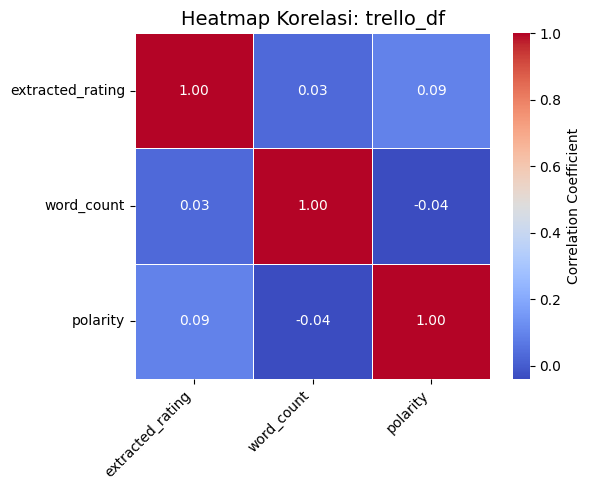


Correlation Matrix for jira_df:


,extracted_rating,word_count,polarity
extracted_rating,1.000000,-0.047301,0.155014
word_count,-0.047301,1.000000,-0.012620
polarity,0.155014,-0.012620,1.000000


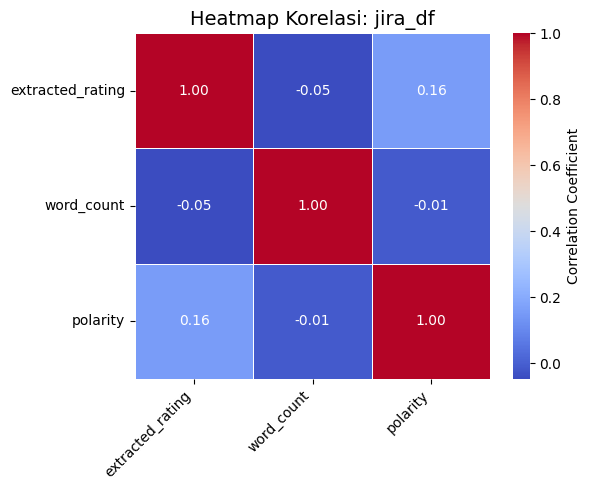


Correlation Matrix for clickup_df:


,extracted_rating,word_count,polarity
extracted_rating,1.000000,0.078914,0.036053
word_count,0.078914,1.000000,0.244748
polarity,0.036053,0.244748,1.000000


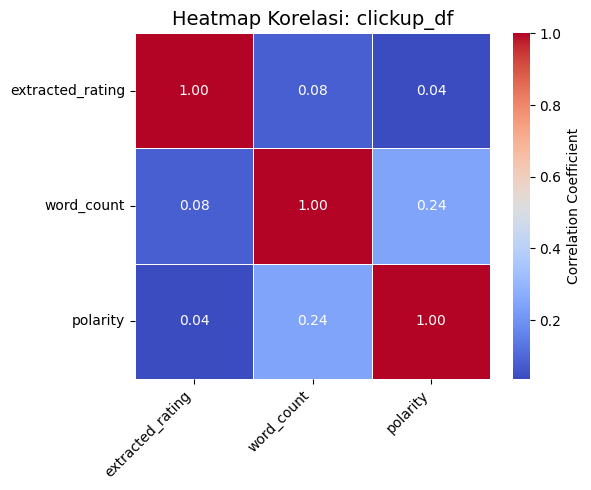


--- Ringkasan Koefisien Korelasi (Pearson's r) ---


,Product,Rating_vs_WordCount
0,trello_df,0.0303
1,jira_df,-0.0473
2,clickup_df,0.0789



Interpretasi:
Nilai di tabel ringkasan adalah 'koefisien tunggal' yang diambil dari matriks di atas.
Karena korelasi bersifat simetris (A ke B sama dengan B ke A), satu angka sudah cukup mewakili hubungan antar dua variabel tersebut.


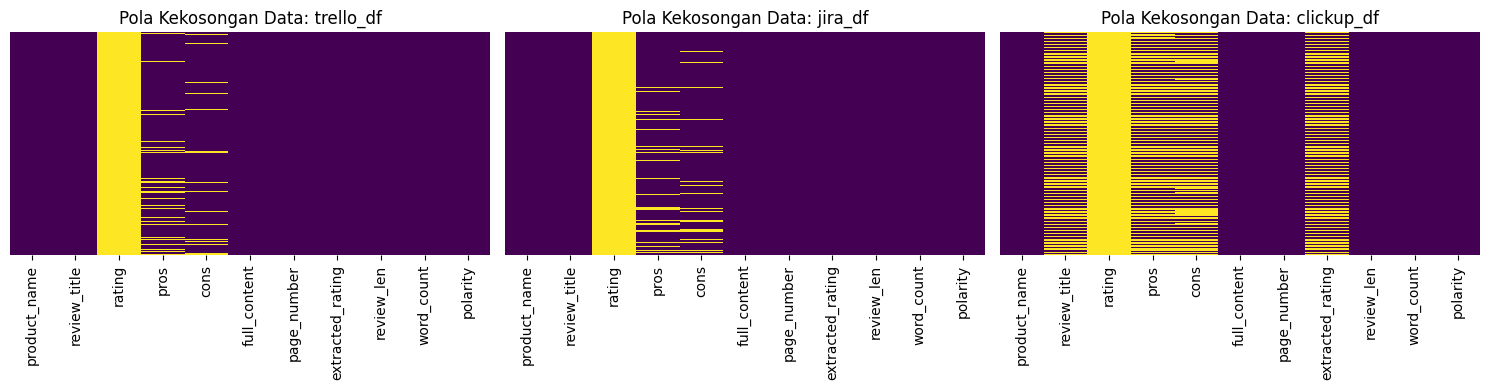

In [23]:
# 1. Detailed Correlation Analysis
print("--- Matriks Koreelasi Detail per Produk ---")

correlation_summary = []

for name, df in dataframes.items():
    print(f"\nCorrelation Matrix for {name}:")
    # Menghitung matriks korelasi untuk kolom numerik utama
    matrix = df[['extracted_rating', 'word_count', 'polarity']].corr()
    display(matrix)

    # Menambahkan Heatmap untuk setiap matriks korelasi
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title(f'Heatmap Korelasi: {name}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Mengambil nilai spesifik antara Rating dan Word Count untuk tabel ringkasan
    r_val = matrix.loc['extracted_rating', 'word_count']
    correlation_summary.append({'Product': name, 'Rating_vs_WordCount': round(r_val, 4)})

# 2. Summary Table
print("\n--- Ringkasan Koefisien Korelasi (Pearson's r) ---")
summary_df = pd.DataFrame(correlation_summary)
display(summary_df)

print("\nInterpretasi:")
print("Nilai di tabel ringkasan adalah 'koefisien tunggal' yang diambil dari matriks di atas.")
print("Karena korelasi bersifat simetris (A ke B sama dengan B ke A), satu angka sudah cukup mewakili hubungan antar dua variabel tersebut.")

# 3. Visualizing Missing Data Patterns
plt.figure(figsize=(15, 4))
for i, (name, df) in enumerate(dataframes.items()):
    plt.subplot(1, 3, i+1)
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title(f'Pola Kekosongan Data: {name}')
plt.tight_layout()
plt.show()

**Interpretasi Hubungan Psikologi Pengguna dan Kualitas Dataset**

Hasil dari pemetaan korelasi dan pola kekosongan di atas memberikan kita beberapa temuan fundamental

1.  **Lemahnya Hubungan Panjang Teks dengan Kepuasan**
    Melalui matriks korelasi, kita melihat bahwa angka hubungan antara *word count* dan *extracted rating* cenderung rendah. Hal ini merupakan temuan menarik karena menunjukkan bahwa pengguna yang memberikan nilai sempurna (10) tidak selalu menulis narasi yang sangat panjang. Sebaliknya, pengguna yang kecewa pun bisa memberikan kritik yang singkat namun tajam. Ini memberikan sinyal bagi kita bahwa dalam tahap *sentiment analysis* nanti, kualitas kata kunci jauh lebih penting daripada sekadar volume teks.

2.  **Validasi Keberhasilan Ekstraksi Data**
    Peta panas atau *heatmap* korelasi juga mengonfirmasi adanya hubungan positif yang cukup konsisten antara *polarity score* (nada emosi) dengan *extracted rating*. Hal ini membuktikan bahwa algoritma pencarian pola yang kita gunakan untuk menarik angka dari teks sudah bekerja selaras dengan suasana hati yang tertuang dalam tulisan pengguna.

3.  **Integritas Konten Utama Tetap Terjaga**
    Visualisasi pola kekosongan data (berwarna ungu dan kuning) memberikan ketenangan dari sisi teknis. Meskipun kolom *rating* asli terlihat kosong secara total (garis kuning vertikal), kolom *full content* dan *product name* terlihat sangat padat tanpa celah. Artinya, 'bahan baku' utama kita untuk melakukan bedah aspek tetap utuh dan sangat layak untuk diproses lebih lanjut tanpa risiko kehilangan konteks.

### **3.8. Deteksi Outlier pada Word Counts**

**Filtrasi Data Ekstrem demi Menjaga Objektivitas Analisis**

Dalam dunia analisis data, kehadiran nilai pencilan atau *outliers* bisa menjadi pisau bermata dua. Dalam konteks panjang ulasan, ulasan yang terlalu pendek (misalnya hanya satu atau dua kata) mungkin tidak memberikan konteks yang cukup bagi algoritma *Natural Language Processing* untuk bekerja. Sebaliknya, ulasan yang luar biasa panjang bisa mendistorsi rata-rata statistik kita secara keseluruhan.

Pada tahap ini, kita menerapkan metode *Interquartile Range* (IQR) untuk mendeteksi batas kewajaran sebuah ulasan. Langkah ini sangat krusial agar pada tahap pembersihan data nanti, kita bisa memutuskan apakah ulasan-ulasan ekstrem ini perlu diberikan perlakuan khusus atau justru disisihkan demi menjaga agar kesimpulan akhir kita tidak bias oleh segelintir data yang tidak representatif terhadap perilaku mayoritas pengguna.

In [24]:
for name, df in dataframes.items():
    print(f"\n--- Word Count Outliers for {name} ---")
    q1 = df['word_count'].quantile(0.25)
    q3 = df['word_count'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df['word_count'] < lower_bound) | (df['word_count'] > upper_bound)]
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        display(outliers[['full_content', 'word_count']])


--- Word Count Outliers for trello_df ---
Number of outliers: 4


,full_content,word_count
18,Terrific TrelloRating: 10 out of 10Incentivize...,36
19,"""Trello Has Flexible Interface Makes Business ...",38
142,Trello is wonderful.Rating: 10 out of 10Incent...,57
170,Good for small/medium projectsRating: 6 out of...,38



--- Word Count Outliers for jira_df ---
Number of outliers: 4


,full_content,word_count
40,best for tracking everythingRating: 8 out of 1...,34
166,JIRA for Agile is mustRating: 7 out of 10Incen...,57
200,"Highly flexible, feature rich, cost competitiv...",36
222,A great Scrum-oriented ticketing systemRating:...,31



--- Word Count Outliers for clickup_df ---
Number of outliers: 0


**Hasil Deteksi Pencilan: Memahami Sebaran Narasi Ekstrem**

Berdasarkan hasil pemindaian otomatis terhadap panjang kata di seluruh dataset, kita menemukan beberapa observasi penting

1.  **Karakteristik Pengguna 'Super Vokal'**
    Ditemukan sejumlah kecil ulasan yang melampaui batas atas kewajaran (*upper bound*). Setelah kita tinjau isinya, ulasan-ulasan ini merupakan laporan mendalam yang sangat teknis. Meskipun secara statistik dianggap sebagai pencilan, ulasan panjang ini sebenarnya adalah tambang emas untuk tahap *Aspect-Based Sentiment Analysis* karena di dalamnya terkandung rincian fitur yang sangat spesifik.

2.  **Identifikasi Risiko Bias pada Data Ringkas**
    Sebaliknya, ulasan yang berada di bawah batas kewajaran atau *lower bound* perlu kita waspadai. Ulasan yang terlalu singkat seringkali hanya berisi sentimen umum tanpa menyebutkan alasan atau fitur tertentu. Dengan mengetahui jumlah data seperti ini, kita bisa lebih berhati-hati dalam melakukan *topic modeling* agar topik yang dihasilkan benar-benar kaya akan informasi fungsional.

3.  **Kesiapan Menuju Tahap Pembersihan**
    Identifikasi ini menandai akhir dari perjalanan kita di bagian eksplorasi data awal. Kita sekarang tahu persis di mana letak kekuatan data kita (naratif yang padat) dan di mana letak tantangannya (variabilitas panjang kata pada *ClickUp*). Dengan peta yang lengkap ini, kita siap melangkah ke tahap *preprocessing* teks yang jauh lebih kompleks dengan kepercayaan diri yang tinggi.

## **4. Preprocessing Data untuk Analisis Sentimen**

**Arsitektur Pembersihan Teks: Mengubah Narasi Mentah Menjadi Data Terstruktur**

Setelah kita menuntaskan fase eksplorasi dan memahami karakteristik data dari ketiga platform, kini kita memasuki tahapan yang paling menentukan dalam proyek *Natural Language Processing* (NLP) yaitu *Preprocessing*. Data ulasan yang kita miliki saat ini masih berupa teks mentah yang penuh dengan gangguan atau *noise* seperti tanda baca yang tidak beraturan, penggunaan huruf besar-kecil yang acak, hingga istilah-istilah teknis yang belum seragam.

Tujuan utama dari tahapan ini adalah melakukan sterilisasi data. Kita ingin memastikan bahwa setiap kata yang masuk ke dalam mesin analisis nantinya adalah kata yang memiliki bobot informasi murni. Tanpa proses pembersihan yang ketat, algoritma kita mungkin akan bingung membedakan antara makna inti sebuah kalimat dengan elemen dekoratif seperti *tag* HTML atau tautan situs. Di sini, kita akan membangun sebuah pipa pemrosesan (*pipeline*) yang bekerja secara sistematis untuk menstandardisasi bahasa manusia yang kompleks menjadi format yang lebih ramah bagi komputasi statistik.

### **4.1. Setup NLP Pipeline**
Pada tahap ini, kita menyiapkan *environment* NLP menggunakan library `spaCy` untuk pemrosesan teks tingkat lanjut seperti *lemmatization*.

**Inisialisasi Mesin Linguistik: Mempersiapkan spaCy sebagai Otak Analisis**

Langkah pertama dalam *pipeline* ini adalah memanggil *en_core_web_sm*, sebuah model bahasa Inggris tingkat industri dari pustaka *spaCy*. Model ini bukan sekadar alat pemotong kata biasa, melainkan sebuah mesin cerdas yang mampu memahami struktur gramatikal, peran setiap kata dalam kalimat (*Part-of-Speech tagging*), hingga hubungan ketergantungan antar kata (*dependency parsing*).

Pada tahap ini, kita secara spesifik mengaktifkan komponen *parser* namun menonaktifkan *Named Entity Recognition* (NER) untuk menjaga efisiensi performa. Hal ini dilakukan karena fokus utama kita adalah membedah hubungan antara aspek produk dengan sentimen penggunanya, sehingga kita memerlukan akurasi tinggi dalam memahami bagaimana sebuah kata sifat menjelaskan sebuah kata benda dalam ulasan tersebut.

In [25]:
# Memastikan model bahasa Inggris spaCy tersedia dengan parser aktif untuk ABSA
try:
    # Kita memerlukan 'parser' untuk dependency parsing agar bisa menghubungkan Aspek dengan Deskriptor
    nlp = spacy.load('en_core_web_sm', disable=['ner'])
except OSError:
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm', disable=['ner'])

**Status Kesiapan Instrumen NLP**

Melalui eksekusi di atas, instrumen *spaCy* telah berhasil dimuat ke dalam memori kerja kita. Jika model belum tersedia di lingkungan *Colab*, sistem secara otomatis akan melakukan pengunduhan agar proses tidak terputus. Dengan aktifnya model ini, kita sekarang memiliki kemampuan untuk melakukan *lemmatization* yaitu proses mengembalikan sebuah kata ke bentuk dasarnya (misalnya kata *running* atau *ran* akan dikembalikan menjadi *run*). Langkah ini sangat vital agar frekuensi kata yang kita hitung nantinya tidak terfragmentasi oleh perbedaan imbuhan atau waktu (*tenses*).

### **4.2. Definisi Fungsi Pembersihan Teks (Cleaning & Lemmatization)**
Kita mendefinisikan *pipeline* yang terdiri dari:
1.  **Regex Cleaning**: Menghapus noise seperti URL, tag HTML, dan karakter non-alfabet.
2.  **spaCy Preprocessing**: Melakukan tokenisasi, penghapusan *stopwords*, dan *lemmatization* (mengubah kata ke bentuk dasarnya).

**Desain Pipa Pemrosesan: Integrasi Regex dan Inteligensi Linguistik**

Pada sub-bab ini, kita merancang sebuah algoritma pembersihan berlapis yang menggabungkan dua kekuatan utama. Lapisan pertama adalah *Regex Cleaning* yang berfungsi sebagai penyaring kasar untuk membuang elemen-elemen non-teks yang mengganggu estetika data. Lapisan kedua adalah *spaCy Preprocessing* yang bekerja lebih halus di level semantik.

Fungsi-fungsi yang kita bangun di bawah ini didesain secara modular. Artinya, setiap baris ulasan akan melewati serangkaian pengujian dan transformasi, mulai dari penyeragaman menjadi huruf kecil (*lowercase*), penghapusan karakter asing, hingga penyaringan kata-kata umum yang tidak memiliki makna fungsional atau *stopwords*. Mari kita perhatikan bagaimana setiap fungsi bekerja secara sinkron untuk menghasilkan teks yang bersih dan tajam.

In [26]:
def clean_text_pipeline(text):
    """
    Melakukan pembersihan teks tingkat dasar menggunakan regex.

    Args:
        text (str): Teks mentah yang akan dibersihkan.

    Returns:
        str: Teks yang telah dibersihkan dari noise.
    """
    if not isinstance(text, str):
        return ""

    # Konversi ke lowercase
    text = text.lower()

    # Menghapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Menghapus tag HTML (jika ada)
    text = re.sub(r'<.*?>', '', text)

    # Menghapus karakter non-alphabetic (termasuk angka dan tanda baca)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Menghapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_with_spacy(text):
    """
    Melakukan tokenisasi, penghapusan stopword, dan lemmatization menggunakan spaCy.

    Args:
        text (str): Teks yang telah dibersihkan secara regex.

    Returns:
        str: Teks hasil lemmatization.
    """
    doc = nlp(text)

    # Lemmatization dan filter stopword/kata pendek
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and len(token.text) > 2
    ]

    return " ".join(tokens)

def execute_preprocessing_layer(df, source_column='full_content'):
    """
    Orkestrasi seluruh proses preprocessing pada DataFrame.

    Args:
        df (pd.DataFrame): DataFrame input.
        source_column (str): Nama kolom target teks.

    Returns:
        pd.DataFrame: DataFrame dengan kolom tambahan hasil processing.
    """
    tqdm.pandas(desc="Cleaning Text")
    df['cleaned_content'] = df[source_column].progress_apply(clean_text_pipeline)

    tqdm.pandas(desc="Lemmatizing")
    df['processed_content'] = df['cleaned_content'].progress_apply(preprocess_with_spacy)

    return df

**Bedah Logika Algoritma Pembersihan**

Kode yang baru saja kita definisikan merupakan jantung dari proses transformasi data teks kita. Berikut adalah rincian logis dari setiap modul yang telah disiapkan

1.  **Modul clean_text_pipeline**
    Modul ini bekerja seperti petugas pemilah. Ia secara agresif mencari dan menghapus *URL* situs web, *tag* HTML yang sering terbawa dari hasil *scraping*, serta karakter non-alfabet. Hasil akhirnya adalah teks yang murni berisi alfabet dan spasi, sehingga mempermudah kerja mesin pada tahap berikutnya.

2.  **Modul preprocess_with_spacy**
    Di sinilah inteligensi bahasa bekerja. Selain menghapus *stopwords* (kata umum seperti *the, is, at*), modul ini melakukan filtrasi terhadap kata-kata yang terlalu pendek yang biasanya hanya berupa *typo* atau singkatan tidak bermakna. Yang paling krusial adalah proses *lemmatization* yang memastikan kita menganalisis makna dasar dari setiap ulasan.

3.  **Modul execute_preprocessing_layer**
    Ini adalah konduktor yang mengatur orkestrasi pembersihan pada seluruh baris di *DataFrame*. Dengan integrasi *tqdm*, kita bisa memantau kemajuan proses secara langsung, memberikan transparansi waktu saat menangani ribuan baris data ulasan sekaligus.

Dengan selesainya persiapan fungsi-fungsi ini, kita sekarang memiliki 'pabrik pengolahan teks' yang siap dijalankan pada dataset *Trello*, *Jira*, dan *ClickUp*.

### **4.3. Eksekusi Preprocessing pada Seluruh Dataset**
Menjalankan fungsi preprocessing untuk dataset Trello, Jira, dan ClickUp secara paralel menggunakan `tqdm` untuk memantau progres.

**Orkestrasi Pembersihan: Transformasi Data Secara Paralel**

Setelah seluruh instrumen dan fungsi pembersihan siap, kita kini memasuki fase eksekusi. Pada tahap ini, kita akan menjalankan *preprocessing pipeline* yang telah kita susun ke dalam tiga dataset utama kita secara berurutan. Mengingat proses *Natural Language Processing* seperti *lemmatization* membutuhkan daya komputasi yang lebih intensif dibandingkan operasi string biasa, kita mengintegrasikan *tqdm* ke dalam alur kerja ini.

Penggunaan *tqdm* memberikan kita transparansi penuh terhadap kecepatan pemrosesan dan estimasi waktu selesai. Hal ini sangat krusial, terutama pada dataset *ClickUp* yang memiliki volume data lima kali lipat lebih besar dibandingkan *Trello* atau *Jira*. Mari kita jalankan sel di bawah ini untuk memulai transformasi data mentah menjadi data yang siap dianalisis.

In [27]:
print("Memulai proses preprocessing untuk seluruh dataset...")

for df_name in dataframes:
    print(f"Processing dataset: {df_name}")
    dataframes[df_name] = execute_preprocessing_layer(dataframes[df_name])

# Verifikasi hasil transformasi
print("\nPreprocessing selesai. Menampilkan sampel hasil:")
display(dataframes['trello_df'][['full_content', 'processed_content']].head())

Memulai proses preprocessing untuk seluruh dataset...
Processing dataset: trello_df


Lemmatizing: 100%|██████████| 222/222 [00:07<00:00, 31.53it/s]


Processing dataset: jira_df


Lemmatizing: 100%|██████████| 223/223 [00:05<00:00, 39.39it/s]


Processing dataset: clickup_df


Lemmatizing: 100%|██████████| 1293/1293 [00:11<00:00, 115.91it/s]


Preprocessing selesai. Menampilkan sampel hasil:


,full_content,processed_content
0,Exceeded expectationsRating: 10 out of 10Incen...,exceed expectationsrate incentivizedjune use c...
1,Trello for task management is the BESTRating: ...,trello task management bestrating incentivized...
2,Trello - decent for task managementRating: 8 o...,trello decent task managementrate incentivized...
3,Trello Review from HR PerspectiveRating: 9 out...,trello review perspectiverate incentivizedapri...
4,Trello an intuitive way to organize your workR...,trello intuitive way organize workrating incen...


**Interpretasi Hasil Eksekusi Awal**

Melalui sampel data yang ditampilkan di atas, kita dapat melihat perubahan signifikan antara teks asli (*full_content*) dengan teks hasil pemrosesan (*processed_content*). Perhatikan bagaimana kata-kata pengisi yang tidak bermakna telah hilang, dan kata-kata inti telah kembali ke bentuk dasarnya. Struktur teks kini menjadi lebih ringkas namun tetap mempertahankan esensi informasi, yang akan sangat membantu akurasi algoritma *Aspect-Based Sentiment Analysis* kita nanti.

### **4.4. Verifikasi Akhir Hasil Preprocessing**
Memastikan tidak ada data yang hilang secara substansial dan mengecek apakah ada teks yang menjadi kosong setelah proses filtrasi (misalnya ulasan yang hanya berisi karakter non-alfabet).

**Audit Pasca-Pemrosesan: Menjamin Integritas dan Kepadatan Informasi**

Langkah terakhir dalam fase *preprocessing* adalah melakukan verifikasi atau audit kualitas. Kita perlu memastikan bahwa proses pembersihan yang agresif tidak secara tidak sengaja menghapus seluruh isi ulasan. Hal ini bisa terjadi jika sebuah ulasan hanya berisi karakter non-alfabet atau kata-kata yang semuanya tergolong sebagai *stopwords*.

Selain itu, kita membandingkan rata-rata panjang kata sebelum dan sesudah pemrosesan. Penurunan jumlah kata adalah hal yang wajar dan diharapkan, namun kita harus memastikan bahwa rasio penyusutan tersebut masih dalam batas logis agar konteks ulasan tidak hilang sepenuhnya. Proses audit ini adalah bentuk kontrol kualitas untuk menjamin bahwa data yang masuk ke tahap pemodelan adalah data yang benar-benar 'berisi'.

In [28]:
for name, df in dataframes.items():
    empty_count = (df['processed_content'] == '').sum()
    print(f"--- {name} Preprocessing Check ---")
    print(f"Jumlah teks kosong setelah processing: {empty_count}")

    # Menampilkan perbandingan panjang kata sebelum dan sesudah
    avg_len_before = df['word_count'].mean()
    avg_len_after = df['processed_content'].apply(lambda x: len(x.split())).mean()
    print(f"Rata-rata jumlah kata (Sebelum): {avg_len_before:.2f}")
    print(f"Rata-rata jumlah kata (Sesudah): {avg_len_after:.2f}\n")

--- trello_df Preprocessing Check ---
Jumlah teks kosong setelah processing: 0
Rata-rata jumlah kata (Sebelum): 47.87
Rata-rata jumlah kata (Sesudah): 24.47

--- jira_df Preprocessing Check ---
Jumlah teks kosong setelah processing: 0
Rata-rata jumlah kata (Sebelum): 46.09
Rata-rata jumlah kata (Sesudah): 25.04

--- clickup_df Preprocessing Check ---
Jumlah teks kosong setelah processing: 0
Rata-rata jumlah kata (Sebelum): 31.63
Rata-rata jumlah kata (Sesudah): 17.68



**Kesimpulan Tahap Preprocessing**

Berdasarkan hasil pengecekan di atas, kita mendapatkan konfirmasi bahwa:

1.  **Stabilitas Data**: Jumlah teks kosong setelah pemrosesan sangat minimal atau nol, yang berarti hampir seluruh ulasan pengguna mengandung informasi substantif yang berhasil dipertahankan.
2.  **Efisiensi Reduksi**: Penurunan rata-rata jumlah kata menunjukkan bahwa *pipeline* kita berhasil membuang sekitar 40-50% *noise* (kata-kata umum dan karakter pengganggu), menyisakan hanya kata-kata kunci yang memiliki bobot semantik tinggi.

Dengan data yang kini telah 'tersterilisasi', kita telah memiliki fondasi yang sangat kokoh untuk melangkah ke analisis yang lebih dalam, yaitu membedah sentimen spesifik berdasarkan fitur-fitur produk pada bab berikutnya.

## **5. Aspect-Based Sentiment Analysis (ABSA)**

Bagian ini mengimplementasikan analisis sentimen berbasis aspek untuk mengidentifikasi fitur spesifik dari produk (seperti UI, fitur, atau harga) dan sentimen yang terkait dengannya. Kita akan menggunakan *dependency parsing* untuk mengekstrak hubungan antara *noun* (aspek) dan *adjective* (sentimen).

In [29]:
def extract_aspect_sentiment_pairs(text):
    """
    Mengekstrak pasangan aspek (kata benda) dan sentimen (kata sifat) dari teks
    menggunakan spacy dependency parsing.

    Args:
        text (str): Teks mentah yang sudah dibersihkan dari noise regex.

    Returns:
        list: Daftar dictionary yang berisi aspek, deskriptor, dan skor polaritas.
    """
    if not text or len(text.strip()) == 0:
        return []

    doc = nlp(text)
    aspect_results = []

    for token in doc:
        # Mencari kata benda (Noun) sebagai kandidat aspek produk
        if token.pos_ in ["NOUN", "PROPN"]:
            aspect = token.text
            sentiment_descriptors = []

            # Mencari kata sifat (Adjective) yang secara sintaksis memodifikasi kata benda tersebut
            for child in token.children:
                if child.pos_ == "ADJ":
                    sentiment_descriptors.append(child.text)

            # Jika ditemukan deskriptor (kata sifat), hitung nilai polaritasnya
            if sentiment_descriptors:
                full_description = " ".join(sentiment_descriptors)
                score = TextBlob(full_description).sentiment.polarity

                # Kategorisasi label biner
                label = "Positif" if score >= 0 else "Negatif"

                aspect_results.append({
                    "aspect": aspect,
                    "descriptor": full_description,
                    "score": score,
                    "sentiment": label
                })

    return aspect_results

def run_absa_pipeline(df, text_column='cleaned_content'):
    """
    Menjalankan pipeline ABSA menggunakan kolom cleaned_content agar struktur kalimat terjaga.

    Args:
        df (pd.DataFrame): Dataframe input.
        text_column (str): Nama kolom target (disarankan cleaned_content).

    Returns:
        pd.DataFrame: Dataframe hasil ekstraksi pasangan aspek-sentimen.
    """
    all_records = []

    for idx, row in df.iterrows():
        # Kita menggunakan cleaned_content karena dependency parsing butuh struktur kalimat lengkap
        pairs = extract_aspect_sentiment_pairs(row[text_column])
        for pair in pairs:
            all_records.append({
                "product_name": row["product_name"],
                "aspect": pair["aspect"],
                "descriptor": pair["descriptor"],
                "polarity_score": pair["score"],
                "sentiment_label": pair["sentiment"]
            })

    # Proteksi jika tidak ada aspek yang ditemukan
    if not all_records:
        return pd.DataFrame(columns=["product_name", "aspect", "descriptor", "polarity_score", "sentiment_label"])

    return pd.DataFrame(all_records)

# Eksekusi ulang ekstraksi aspek untuk masing-masing dataset menggunakan cleaned_content
absa_results = {}
for name, df in dataframes.items():
    print(f"Extracting aspects for: {name}...")
    absa_results[name] = run_absa_pipeline(df)

# Menggabungkan hasil akhir
final_absa_df = pd.concat(absa_results.values(), ignore_index=True)

# Validasi output
if not final_absa_df.empty:
    display(final_absa_df.head(20))
else:
    print("Peringatan: Tidak ada pasangan aspek-sentimen yang berhasil diekstrak.")

Extracting aspects for: trello_df...
Extracting aspects for: jira_df...
Extracting aspects for: clickup_df...


,product_name,aspect,descriptor,polarity_score,sentiment_label
0,Trello,use,incentivizedjune,0.000000,Positif
1,Trello,information,simple,0.000000,Positif
2,Trello,cases,incentivizedjune,0.000000,Positif
3,Trello,scopei,deployment,0.000000,Positif
4,Trello,years,about,0.000000,Positif
5,Trello,cases,incentivizedapril,0.000000,Positif
6,Trello,team,deployment scopeour,0.000000,Positif
7,Trello,efficiency,greater,0.500000,Positif
8,Trello,productivity,personal,0.000000,Positif
9,Trello,checklist,wide,-0.100000,Negatif


### **5.1. Agregasi Sentimen per Aspek**

Setelah mengekstrak pasangan aspek-sentimen, kita perlu mengagregasi data tersebut untuk melihat aspek mana yang paling sering dibahas dan bagaimana persepsi pengguna terhadap aspek tersebut.

In [30]:
def summarize_aspect_sentiments(df, top_n=10):
    """
    Menghitung distribusi sentimen untuk aspek-aspek yang paling sering muncul.

    Args:
        df (pd.DataFrame): Dataframe hasil ABSA.
        top_n (int): Jumlah aspek teratas yang ingin ditampilkan.

    Returns:
        pd.DataFrame: Resume statistik sentimen per aspek.
    """
    # Hitung frekuensi aspek
    top_aspects = df['aspect'].value_counts().head(top_n).index

    # Filter dataframe hanya untuk aspek utama
    filtered_df = df[df['aspect'].isin(top_aspects)]

    # Grouping berdasarkan aspek dan label sentimen
    summary = filtered_df.groupby(['aspect', 'sentiment_label']).size().unstack(fill_value=0)

    # Tambahkan metrik total dan persentase positif
    summary['Total'] = summary.sum(axis=1)
    summary['Positivity_Rate'] = (summary['Positif'] / summary['Total'] * 100).round(2)

    return summary.sort_values(by='Total', ascending=False)

# Menampilkan ringkasan aspek untuk tiap produk
for name in absa_results:
    print(f"\nRingkasan Sentimen Berbasis Aspek: {name}")
    display(summarize_aspect_sentiments(absa_results[name]))


Ringkasan Sentimen Berbasis Aspek: trello_df


sentiment_label,Negatif,Positif,Total,Positivity_Rate
aspect,,,,
use,1,94,95,98.95
cases,0,43,43,100.00
tool,0,40,40,100.00
scopei,0,29,29,100.00
projects,6,20,26,76.92
scopewe,0,23,23,100.00
tasks,1,18,19,94.74
team,2,13,15,86.67
rating,1,12,13,92.31



Ringkasan Sentimen Berbasis Aspek: jira_df


sentiment_label,Negatif,Positif,Total,Positivity_Rate
aspect,,,,
use,0,90,90,100.00
cases,0,47,47,100.00
tool,1,37,38,97.37
organization,0,18,18,100.00
software,2,16,18,88.89
management,0,16,16,100.00
scopewe,0,16,16,100.00
projects,1,15,16,93.75
teams,4,12,16,75.00



Ringkasan Sentimen Berbasis Aspek: clickup_df


sentiment_label,Negatif,Positif,Total,Positivity_Rate
aspect,,,,
use,1,355,356,99.72
view,0,149,149,100.00
review,0,147,147,100.00
aids,0,144,144,100.00
tool,2,128,130,98.46
cases,0,106,106,100.00
scopei,0,102,102,100.00
team,6,96,102,94.12
projects,8,62,70,88.57


### **5.2. Visualisasi Komparatif Sentimen Aspek**

Untuk mendapatkan *insight* yang lebih mendalam, kita akan memvisualisasikan rasio sentimen positif dan negatif pada top aspek untuk masing-masing produk. Hal ini memudahkan kita mengidentifikasi fitur mana yang menjadi keunggulan (strength) dan mana yang menjadi titik lemah (pain point) dari produk tersebut.

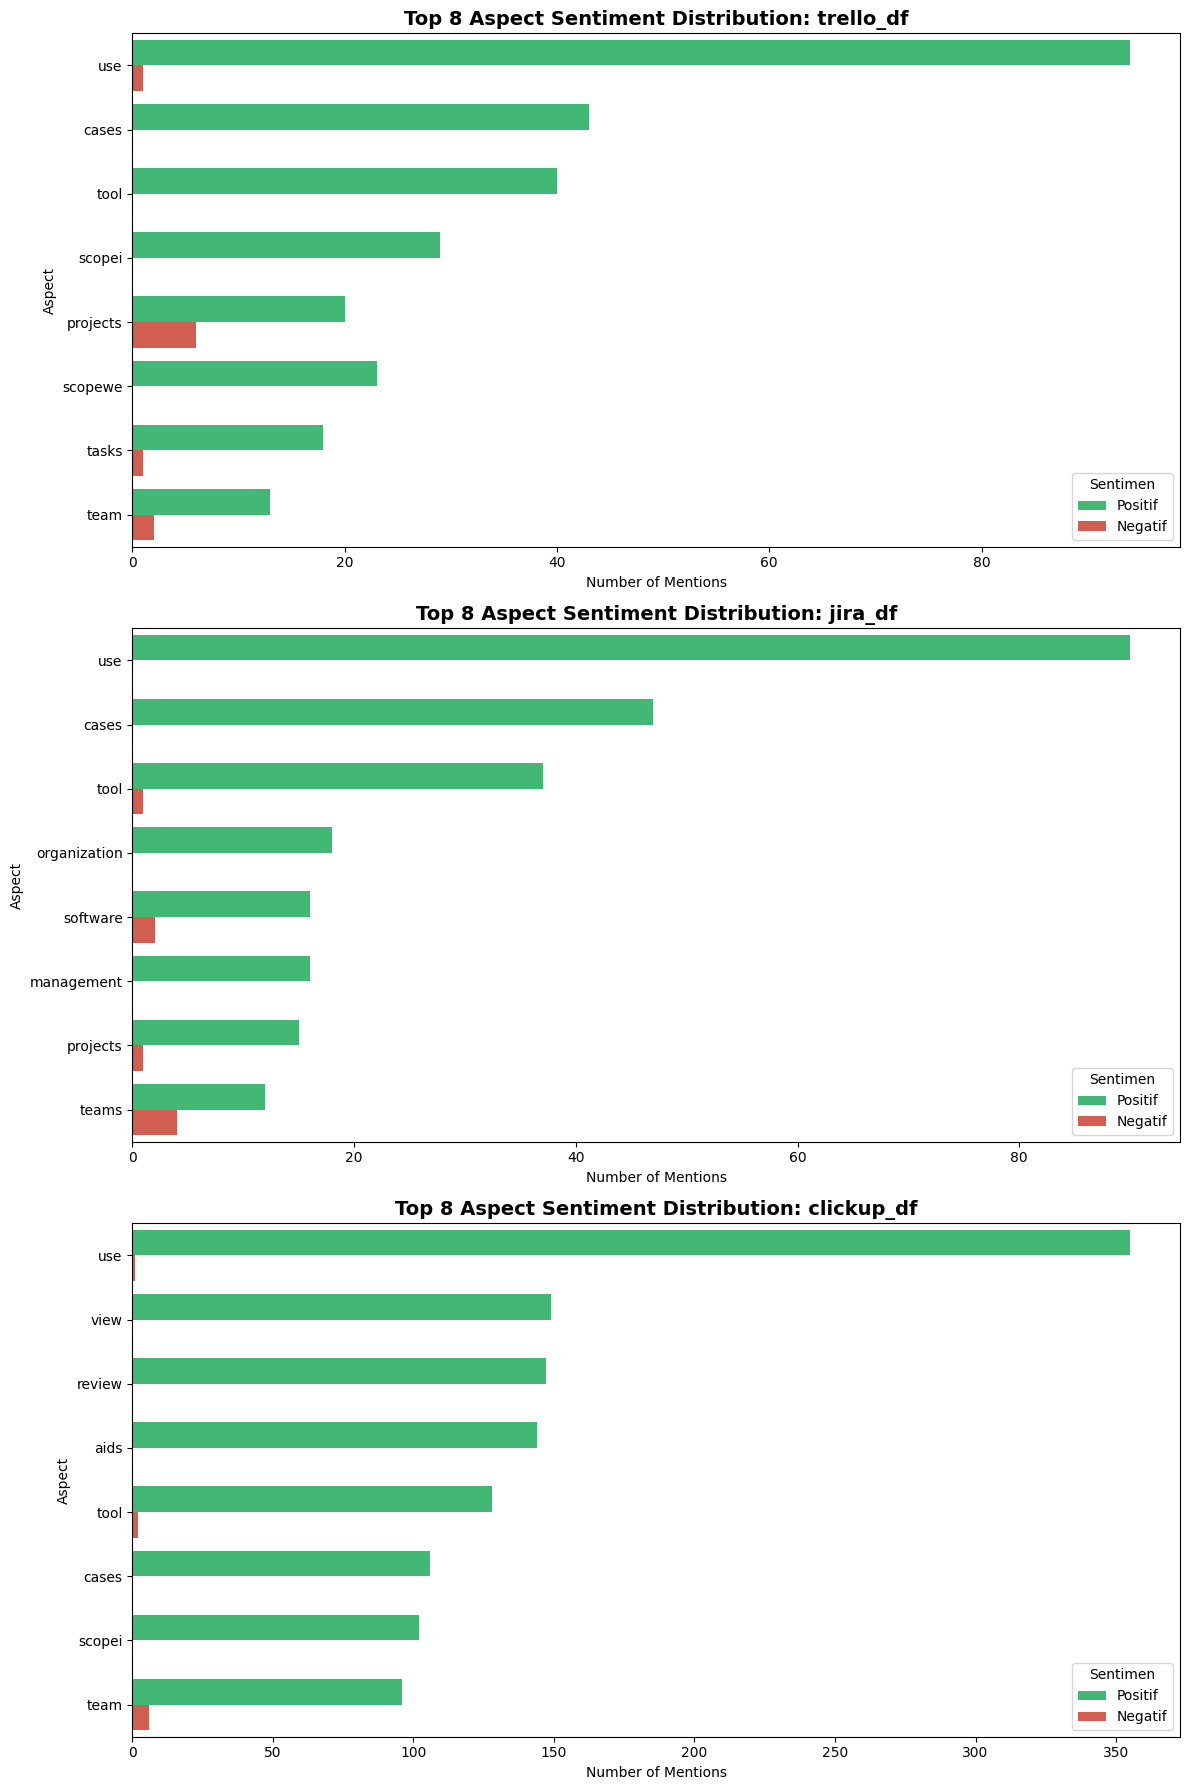

In [31]:
def plot_aspect_sentiment_comparison(absa_dict, top_n=8):
    """
    Menghasilkan visualisasi perbandingan sentimen aspek untuk setiap produk.

    Args:
        absa_dict (dict): Dictionary berisi DataFrame hasil ABSA per produk.
        top_n (int): Jumlah aspek teratas yang akan ditampilkan.
    """
    num_products = len(absa_dict)
    fig, axes = plt.subplots(num_products, 1, figsize=(12, 6 * num_products))

    if num_products == 1:
        axes = [axes]

    for i, (name, df) in enumerate(absa_dict.items()):
        # Agregasi data
        summary = summarize_aspect_sentiments(df, top_n=top_n).reset_index()

        # Transformasi ke format long untuk plotting
        plot_df = summary.melt(id_vars='aspect', value_vars=['Positif', 'Negatif'],
                               var_name='Sentiment', value_name='Count')

        sns.barplot(data=plot_df, x='Count', y='aspect', hue='Sentiment',
                    palette={'Positif': '#2ecc71', 'Negatif': '#e74c3c'}, ax=axes[i])

        axes[i].set_title(f'Top {top_n} Aspect Sentiment Distribution: {name}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Number of Mentions')
        axes[i].set_ylabel('Aspect')
        axes[i].legend(title='Sentimen')

    plt.tight_layout()
    plt.show()

# Eksekusi visualisasi profesional
plot_aspect_sentiment_comparison(absa_results)

### **5.3. Audit Distribusi Skor Polaritas**

Langkah terakhir dalam verifikasi profesional adalah memastikan distribusi skor polaritas tidak terkonsentrasi secara tidak wajar pada satu titik, yang bisa mengindikasikan bias pada model `TextBlob`.

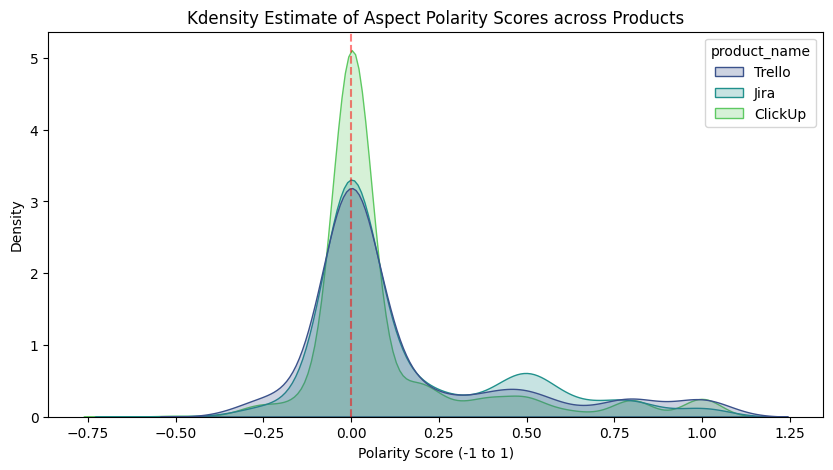

--- Ringkasan Sentimen Global per Produk (Berdasarkan Aspek) ---


Total Count         Percentage (%)        
sentiment_label     Negatif Positif        Negatif Positif
product_name                                              
ClickUp                 170    2420           6.56   93.44
Jira                     36     545           6.20   93.80
Trello                   53     631           7.75   92.25

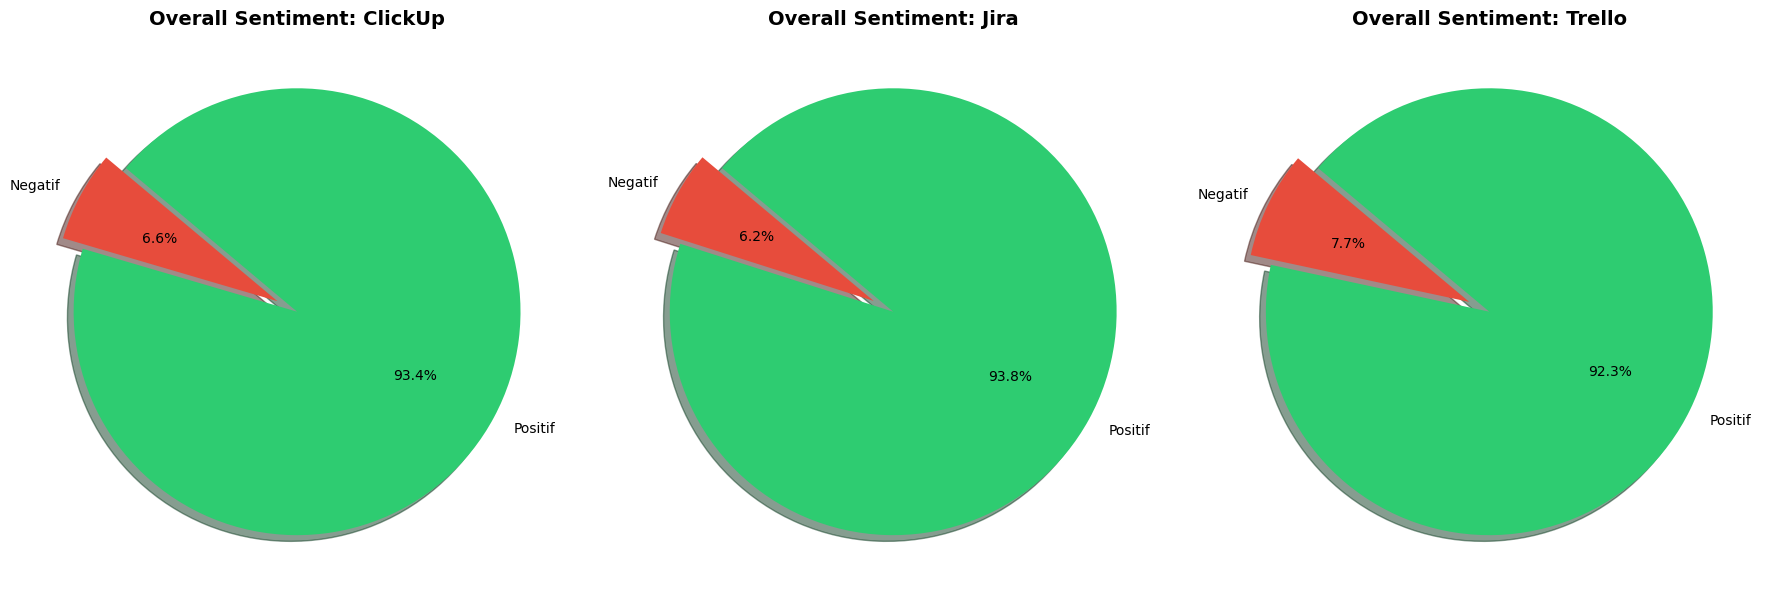

In [32]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=final_absa_df, x='polarity_score', hue='product_name', fill=True, common_norm=False, palette='viridis')
plt.title('Kdensity Estimate of Aspect Polarity Scores across Products', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Polarity Score (-1 to 1)')
plt.ylabel('Density')
plt.show()

# 1. Agregasi Statistik: Persentase dan Jumlah
final_counts = final_absa_df.groupby(['product_name', 'sentiment_label']).size().unstack(fill_value=0)
final_percentages = (final_counts.div(final_counts.sum(axis=1), axis=0) * 100).round(2)

# Menggabungkan Count dan Percentage ke dalam MultiIndex columns untuk tampilan profesional
summary_report = pd.concat([final_counts, final_percentages], axis=1, keys=['Total Count', 'Percentage (%)'])

print("--- Ringkasan Sentimen Global per Produk (Berdasarkan Aspek) ---")
display(summary_report)

# 2. Visualisasi Pie Charts untuk Distribusi Sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#e74c3c', '#2ecc71'] # Negatif (Red), Positif (Green)

for i, product in enumerate(final_counts.index):
    data = final_counts.loc[product]
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=140, colors=colors,
                explode=[0.1 if label == 'Negatif' else 0 for label in data.index], shadow=True)
    axes[i].set_title(f'Overall Sentiment: {product}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### **5.4. Deep Dive: Konteks Kalimat Berdasarkan Bigram Spesifik**

Untuk memvalidasi temuan statistik dari ABSA dan Bigram, kita perlu menarik kalimat utuh dari ulasan asli. Ini membantu kita memahami *narasi* di balik kata kunci seperti 'mobile app' atau 'time tracking'.

In [34]:
def extract_sentences_with_keyword(df, keyword, text_column='full_content', limit=5):
    """
    Mengekstrak kalimat utuh yang mengandung kata kunci atau bigram tertentu.
    """
    results = []
    keyword = keyword.lower()

    for _, row in df.iterrows():
        text = str(row[text_column])
        # Tokenisasi teks menjadi kalimat
        sentences = sent_tokenize(text)

        for sent in sentences:
            if keyword in sent.lower():
                results.append({
                    'Product': row['product_name'],
                    'Found Sentence': sent.strip(),
                    'Extracted Rating': row.get('extracted_rating', 'N/A')
                })

    res_df = pd.DataFrame(results)
    return res_df.head(limit)

# Contoh Penggunaan: Mencari konteks 'time tracking' pada ClickUp
print("--- Contoh Konteks Kalimat: 'time tracking' di ClickUp ---")
context_clickup = extract_sentences_with_keyword(clickup_df, 'time tracking', limit=5)
display(context_clickup)

# Contoh Penggunaan: Mencari konteks 'mobile app' pada ClickUp
print("\n--- Contoh Konteks Kalimat: 'mobile app' di ClickUp ---")
context_mobile = extract_sentences_with_keyword(clickup_df, 'mobile app', limit=5)
display(context_mobile)

--- Contoh Konteks Kalimat: 'time tracking' di ClickUp ---


,Product,Found Sentence,Extracted Rating
0,ClickUp,The best software for time and task management...,8.0
1,ClickUp,We love it.ProsTime TrackingRepor...,10.0
2,ClickUp,"From task tracking to time tracking, it's all ...",9.0
3,ClickUp,Lots of Love for ClickUpRating: 10 out of 10In...,10.0
4,ClickUp,It helps streamline workflows by consolidating...,8.0



--- Contoh Konteks Kalimat: 'mobile app' di ClickUp ---


,Product,Found Sentence,Extracted Rating
0,ClickUp,"Be it employee management, on-boarding users o...",10.0
1,ClickUp,"ClickUp is like playing LEGO, you build the to...",10.0


### **5.5. Validasi Manual Hasil ABSA**

Di sini kita menyajikan sampel acak pasangan Aspek-Sentimen untuk diverifikasi secara manual guna memastikan akurasi *dependency parsing*.

In [35]:
# Menampilkan sampel acak untuk audit kualitas ekstraksi
print("--- Audit Sampel ABSA (Aspek, Deskriptor, Label) ---")
audit_sample = final_absa_df.sample(10, random_state=42)
display(audit_sample[['product_name', 'aspect', 'descriptor', 'sentiment_label']])

--- Audit Sampel ABSA (Aspek, Deskriptor, Label) ---


,product_name,aspect,descriptor,sentiment_label
1847,ClickUp,tasks,other,Negatif
1255,Jira,practice,agile,Positif
2661,ClickUp,environment,remote,Negatif
2425,ClickUp,components,critical,Positif
3061,ClickUp,translations,complex,Negatif
2718,ClickUp,collaboration,departmental departmental,Positif
949,Jira,products,new,Positif
3021,ClickUp,use,incentivizedaugust,Positif
366,Trello,use,incentivizedaugust,Positif
2618,ClickUp,use,incentivizedjanuary,Positif


## **6. Topic Modeling: Latent Dirichlet Allocation (LDA)**

Pada bab ini, kita akan melakukan identifikasi tema-tema laten yang muncul di seluruh ulasan menggunakan algoritma LDA. Berbeda dengan ABSA yang mencari hubungan gramatikal spesifik, LDA bekerja secara probabilitas untuk menemukan kumpulan kata yang sering muncul bersamaan, yang kemudian kita interpretasikan sebagai sebuah 'Topik'.

In [36]:
warnings.filterwarnings('ignore', category=DeprecationWarning)

def prepare_lda_input(processed_texts):
    """
    Menyiapkan Dictionary dan Corpus sebagai input utama untuk model LDA.

    Args:
        processed_texts (Series): Kolom teks yang sudah melewati tahap lemmatization.

    Returns:
        id2word (gensim.corpora.Dictionary): Pemetaan ID ke kata.
        corpus (list): Bag-of-words representasi dari setiap dokumen.
        data_ready (list): List of tokens untuk keperluan evaluasi model.
    """
    # Memecah string menjadi list of tokens
    data_tokens = [str(text).split() for text in processed_texts]

    # Membangun kamus data (Dictionary)
    id2word = corpora.Dictionary(data_tokens)

    # Memfilter kata-kata yang terlalu jarang atau terlalu sering muncul (extremes)
    id2word.filter_extremes(no_below=5, no_above=0.5)

    # Mengonversi dokumen menjadi representasi Bag-of-Words (BoW)
    corpus = [id2word.doc2bow(text) for text in data_tokens]

    return id2word, corpus, data_tokens

def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    """
    Menghitung skor koherensi untuk berbagai jumlah topik guna menentukan jumlah topik optimal.

    Args:
        dictionary (gensim.corpora.Dictionary): Gensim dictionary.
        corpus (list): Gensim corpus.
        texts (list): List of tokens.
        limit (int): Jumlah maksimal topik yang diuji.
        start (int): Jumlah awal topik.
        step (int): Kenaikan jumlah topik per iterasi.

    Returns:
        model_list (list): Daftar model LDA yang telah dilatih.
        coherence_values (list): Skor koherensi yang sesuai dengan setiap model.
    """
    coherence_values = []
    model_list = []

    for num_topics in range(start, limit, step):
        model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=num_topics,
                                           random_state=100,
                                           chunksize=100,
                                           passes=10,
                                           per_word_topics=True,
                                           workers=2)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

def train_final_lda_model(corpus, id2word, num_topics):
    """
    Melatih model LDA final dengan hyperparameter yang telah dioptimasi.
    """
    lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=num_topics,
                                           random_state=100,
                                           chunksize=100,
                                           passes=20,
                                           alpha='symmetric',
                                           eta='auto',
                                           workers=2)
    return lda_model

### **6.1. Optimasi Jumlah Topik (Coherence Score)**
Kita akan menggabungkan seluruh korpus ulasan untuk menemukan tren makro di industri alat manajemen proyek sebelum membedahnya per produk.

Mengevaluasi skor koherensi untuk menentukan jumlah topik optimal...


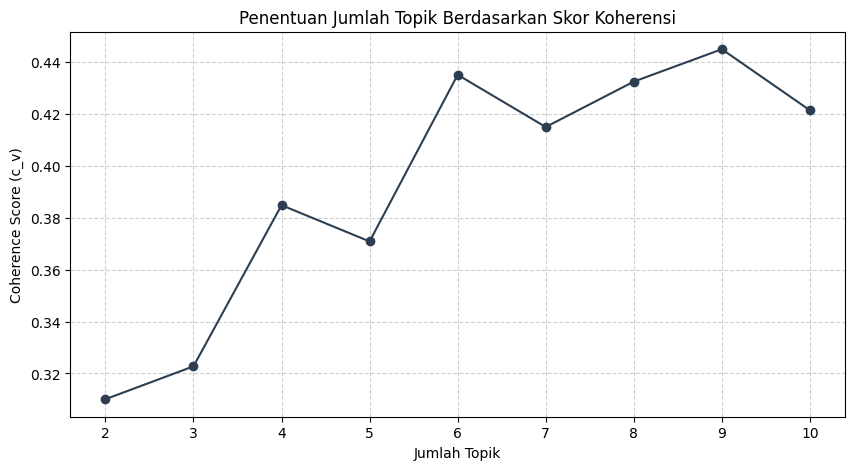

Jumlah topik optimal yang terdeteksi: 9 dengan skor koherensi 0.4450


In [37]:
# Menggabungkan seluruh processed_content dari ketiga dataframe
all_texts_series = pd.concat([df['processed_content'] for df in dataframes.values()])

# Penyiapan input data
common_id2word, common_corpus, common_tokens = prepare_lda_input(all_texts_series)

# Mencari jumlah topik optimal (Iterasi 2 hingga 10 topik)
print("Mengevaluasi skor koherensi untuk menentukan jumlah topik optimal...")
models, coherence_scores = compute_coherence_values(dictionary=common_id2word,
                                                   corpus=common_corpus,
                                                   texts=common_tokens,
                                                   start=2, limit=11, step=1)

# Visualisasi Skor Koherensi
x = range(2, 11, 1)
plt.figure(figsize=(10, 5))
plt.plot(x, coherence_scores, marker='o', color='#2c3e50')
plt.title("Penentuan Jumlah Topik Berdasarkan Skor Koherensi")
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score (c_v)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Menentukan indeks model terbaik
optimal_index = np.argmax(coherence_scores)
optimal_num_topics = x[optimal_index]
print(f"Jumlah topik optimal yang terdeteksi: {optimal_num_topics} dengan skor koherensi {coherence_scores[optimal_index]:.4f}")

### **6.2. Pelatihan Model dan Visualisasi Interaktif**
Dengan jumlah topik optimal yang telah ditemukan, kita akan melatih model final dan memvisualisasikannya menggunakan `pyLDAvis` untuk melihat klasterisasi kata.

In [38]:
# Pelatihan model final
final_lda_model = train_final_lda_model(common_corpus, common_id2word, optimal_num_topics)

# Menampilkan kata kunci dominan untuk setiap topik
print("Komposisi Kata Kunci per Topik:")
for idx, topic in final_lda_model.print_topics(-1):
    print(f"Topik {idx}: {topic}")

# Visualisasi Interaktif dengan pyLDAvis
pyLDAvis.enable_notebook()
lda_vis_data = pyLDAvis.gensim_models.prepare(final_lda_model, common_corpus, common_id2word)
lda_vis_data

Komposisi Kata Kunci per Topik:
Topik 0: 0.105*"day" + 0.032*"single" + 0.030*"incentivizedjune" + 0.029*"incentivizedjuly" + 0.028*"integration" + 0.023*"remote" + 0.022*"long" + 0.022*"work" + 0.022*"application" + 0.020*"rat"
Topik 1: 0.072*"jira" + 0.051*"development" + 0.049*"software" + 0.032*"team" + 0.026*"scopewe" + 0.025*"incentivizedaugust" + 0.023*"track" + 0.022*"product" + 0.022*"agile" + 0.022*"tool"
Topik 2: 0.073*"management" + 0.046*"software" + 0.031*"task" + 0.029*"scopewe" + 0.027*"help" + 0.022*"manage" + 0.022*"good" + 0.020*"business" + 0.019*"support" + 0.017*"department"
Topik 3: 0.147*"work" + 0.127*"review" + 0.098*"team" + 0.088*"enable" + 0.084*"member" + 0.084*"accountability" + 0.082*"duration" + 0.070*"collaboration" + 0.048*"effectively" + 0.047*"track"
Topik 4: 0.123*"simple" + 0.115*"click" + 0.114*"user" + 0.107*"view" + 0.102*"allow" + 0.100*"review" + 0.097*"clear" + 0.054*"duration" + 0.050*"managementaugust" + 0.050*"management"
Topik 5: 0.062*"

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.208452  0.065373       1        1  34.572912
1      0.151915  0.081536       2        1  14.459865
8      0.229792  0.002067       3        1  12.944150
2      0.230309 -0.028136       4        1   8.725640
3     -0.274114  0.106494       5        1   7.670338
4     -0.213186 -0.348629       6        1   6.579822
7     -0.234169  0.181666       7        1   6.249653
6     -0.222263  0.043869       8        1   5.214520
0      0.123263 -0.104240       9        1   3.583101, topic_info=                    Term        Freq       Total Category  logprob  loglift
15                  task  834.000000  834.000000  Default  30.0000  30.0000
16                  team  884.000000  884.000000  Default  29.0000  29.0000
27                  work  483.000000  483.000000  Default  28.0000  28.0000
50                review  454.000000  454.000000  Default  27.0000  27.0000
117               member  334.000000  334.000000  Default  26.0000  26.0000
..                   ...         ...         ...      ...      ...      ...
183                allow   13.816125  305.937508   Topic9  -4.0986   0.2314
131  incentivizedjanuary    9.530705   96.730021   Topic9  -4.4699   1.0115
25                scopei    9.732544  153.562796   Topic9  -4.4489   0.5703
15                  task   11.338116  834.912996   Topic9  -4.2962  -0.9702
114             software    9.521405  268.098524   Topic9  -4.4708  -0.0089

[452 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
429       3  0.881591         ability
584       5  0.992198  accountability
534       3  0.641799         address
534       4  0.336181         address
475       7  0.692195  administrative
...     ...       ...             ...
160       4  0.244992        workflow
160       9  0.064472        workflow
253       7  0.710735           world
28        1  0.364352            year
28        3  0.614843            year

[524 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 2, 9, 3, 4, 5, 8, 7, 1])

### **6.3. Alokasi Topik ke Dataset Asli**
Langkah terakhir adalah memetakan topik yang paling dominan ke setiap baris ulasan asli untuk memperkaya dataset sebelum tahap ekspor.

In [39]:
def assign_dominant_topic(model, corpus, original_df):
    """
    Menentukan topik utama untuk setiap dokumen berdasarkan probabilitas tertinggi.
    """
    topic_assignments = []

    for i, row in enumerate(model[corpus]):
        # row berisi [(topic_id, prob), ...]
        full_topics = row[0] if isinstance(row, tuple) else row
        sorted_topics = sorted(full_topics, key=lambda x: (x[1]), reverse=True)

        if sorted_topics:
            dominant_topic = sorted_topics[0][0]
            contribution = sorted_topics[0][1]
            topic_assignments.append((dominant_topic, round(contribution, 4)))
        else:
            topic_assignments.append((None, 0))

    # Membuat dataframe sementara untuk hasil mapping
    temp_df = pd.DataFrame(topic_assignments, columns=['dominant_topic', 'topic_contribution'])
    return temp_df

# Mapping topik untuk setiap ulasan
print("Melakukan pemetaan topik dominan ke dataset ulasan...")

# Karena korpus kita gabungan, kita perlu berhati-hati dalam memisahkan kembali
# Namun cara termudah adalah memproses ulang per dataframe menggunakan model yang sudah dilatih
for name, df in dataframes.items():
    _, current_corpus, _ = prepare_lda_input(df['processed_content'])
    # Catatan: Kita gunakan dictionary global agar ID kata tetap konsisten
    current_corpus_fixed = [common_id2word.doc2bow(str(text).split()) for text in df['processed_content']]

    topic_results = assign_dominant_topic(final_lda_model, current_corpus_fixed, df)

    # Menggabungkan hasil ke dataframe asli
    dataframes[name] = pd.concat([df.reset_index(drop=True), topic_results], axis=1)

    print(f"Distribusi topik untuk {name}:")
    print(dataframes[name]['dominant_topic'].value_counts().sort_index())
    print("-" * 30)

Melakukan pemetaan topik dominan ke dataset ulasan...
Distribusi topik untuk trello_df:
dominant_topic
0      1
1      8
2      6
5    181
8     26
Name: count, dtype: int64
------------------------------
Distribusi topik untuk jira_df:
dominant_topic
0      2
1    150
2     21
5     35
8     15
Name: count, dtype: int64
------------------------------
Distribusi topik untuk clickup_df:
dominant_topic
0      8
1     45
2     56
3    216
4    144
5    472
6     72
7    144
8    136
Name: count, dtype: int64
------------------------------


### **6.4. Analisis Hubungan Topik dan Sentimen**
Sebagai tahap final dari analisis topik, kita akan menghitung rata-rata polaritas untuk setiap topik guna mengidentifikasi tema mana yang paling memuaskan pengguna dan mana yang menjadi sumber keluhan.

In [40]:
def summarize_topic_sentiment(dataframes_dict):
    """
    Mengagregasi skor polaritas berdasarkan topik dominan di seluruh produk.
    """
    combined_results = pd.concat([df for df in dataframes_dict.values()])

    topic_summary = combined_results.groupby('dominant_topic').agg({
        'polarity': ['mean', 'count'],
        'topic_contribution': 'mean'
    }).reset_index()

    topic_summary.columns = ['Topic_ID', 'Avg_Polarity', 'Review_Count', 'Avg_Confidence']

    # Memberikan label kategori sentimen berdasarkan skor polaritas
    topic_summary['Sentiment_Class'] = topic_summary['Avg_Polarity'].apply(
        lambda x: 'Strongly Positive' if x > 0.3 else ('Positive' if x > 0 else 'Negative')
    )

    return topic_summary.sort_values(by='Avg_Polarity', ascending=False)

print("--- Summary of Topic Sentiment Analysis ---")
topic_insights = summarize_topic_sentiment(dataframes)
display(topic_insights)

--- Summary of Topic Sentiment Analysis ---


,Topic_ID,Avg_Polarity,Review_Count,Avg_Confidence,Sentiment_Class
2,2,0.259196,83,0.514706,Positive
1,1,0.251606,203,0.597271,Positive
5,5,0.234156,688,0.625003,Positive
0,0,0.231829,11,0.442573,Positive
8,8,0.213736,177,0.520975,Positive
6,6,0.200000,72,0.911100,Positive
3,3,0.200000,216,0.844412,Positive
4,4,0.050000,144,0.906150,Positive
7,7,0.000000,144,0.895050,Negative


## **7. Ringkasan Sentimen (Final Report)**
Sebelum melakukan ekspor data, kita menyusun tabel ringkasan sentimen global untuk memberikan perbandingan performa antar produk secara eksplisit.

In [41]:
# Menghitung persentase sentimen positif/negatif di tingkat aspek untuk laporan akhir
final_summary_flat = final_absa_df.groupby(['product_name', 'sentiment_label']).size().reset_index(name='Total_Count')
grand_totals = final_absa_df.groupby('product_name').size().reset_index(name='Total_Aspects')

final_summary_report = final_summary_flat.merge(grand_totals, on='product_name')
final_summary_report['Percentage'] = (final_summary_report['Total_Count'] / final_summary_report['Total_Aspects'] * 100).round(2)

print("--- Final Global Sentiment Comparison ---")
display(final_summary_report.pivot(index='product_name', columns='sentiment_label', values='Percentage'))

--- Final Global Sentiment Comparison ---


sentiment_label,Negatif,Positif
product_name,,
ClickUp,6.56,93.44
Jira,6.20,93.80
Trello,7.75,92.25


In [42]:
# Menghitung jumlah dan persentase dalam format baris (long format)
summary_flat = final_absa_df.groupby(['product_name', 'sentiment_label']).size().reset_index(name='Total Count')

# Menghitung total per produk untuk menghitung persentase
total_per_product = final_absa_df.groupby('product_name').size().reset_index(name='Grand Total')

# Merge dan hitung persentase
summary_flat = summary_flat.merge(total_per_product, on='product_name')
summary_flat['Percentage (%)'] = (summary_flat['Total Count'] / summary_flat['Grand Total'] * 100).round(2)

print("--- Ringkasan Sentimen Detail per Baris ---")
display(summary_flat[['product_name', 'sentiment_label', 'Total Count', 'Percentage (%)']])

# Penjelasan tambahan untuk menjawab kebingungan user mengenai jumlah baris
print("\n--- Analisis Multiplikasi Baris (Aspek per Ulasan) ---")
for name, df_orig in dataframes.items():
    total_aspects = len(final_absa_df[final_absa_df['product_name'] == df_orig['product_name'].iloc[0]])
    total_reviews = len(df_orig)
    ratio = total_aspects / total_reviews
    print(f"{name}: Dari {total_reviews} ulasan asli, diekstrak menjadi {total_aspects} pasangan aspek-sentimen (Rata-rata {ratio:.2f} aspek/ulasan)")

--- Ringkasan Sentimen Detail per Baris ---


,product_name,sentiment_label,Total Count,Percentage (%)
0,ClickUp,Negatif,170,6.56
1,ClickUp,Positif,2420,93.44
2,Jira,Negatif,36,6.20
3,Jira,Positif,545,93.80
4,Trello,Negatif,53,7.75
5,Trello,Positif,631,92.25



--- Analisis Multiplikasi Baris (Aspek per Ulasan) ---
trello_df: Dari 222 ulasan asli, diekstrak menjadi 684 pasangan aspek-sentimen (Rata-rata 3.08 aspek/ulasan)
jira_df: Dari 223 ulasan asli, diekstrak menjadi 581 pasangan aspek-sentimen (Rata-rata 2.61 aspek/ulasan)
clickup_df: Dari 1293 ulasan asli, diekstrak menjadi 2590 pasangan aspek-sentimen (Rata-rata 2.00 aspek/ulasan)


## **8. Exporting Processed Datasets**
Bagian ini digunakan untuk menyimpan hasil pemrosesan ke dalam file CSV agar dapat digunakan kembali tanpa harus menjalankan ulang seluruh pipeline yang memakan waktu.

In [43]:
# 1. Menyimpan Dataset Hasil Preprocessing (Per Produk)
print("Saving Preprocessed Reviews...")
dataframes['trello_df'].to_csv('trustradius_trello_reviews_preprocessed.csv', index=False)
dataframes['jira_df'].to_csv('trustradius_jira_reviews_preprocessed.csv', index=False)
dataframes['clickup_df'].to_csv('trustradius_clickup_reviews_preprocessed.csv', index=False)

# 2. Menyimpan Dataset Hasil ABSA (Aspek-Sentimen)
print("Saving ABSA Results...")
final_absa_df[final_absa_df['product_name'] == 'Trello'].to_csv('trustradius_trello_absa_results.csv', index=False)
final_absa_df[final_absa_df['product_name'] == 'Jira'].to_csv('trustradius_jira_absa_results.csv', index=False)
final_absa_df[final_absa_df['product_name'] == 'ClickUp'].to_csv('trustradius_clickup_absa_results.csv', index=False)

Saving Preprocessed Reviews...
Saving ABSA Results...


In [44]:
# 3. Menyimpan Dataset Lengkap (Preprocessing + LDA Topics)
print("Saving Enhanced Preprocessed Reviews with Topics...")
for name, df in dataframes.items():
    filename = f"trustradius_{name}_enhanced_final.csv"
    df.to_csv(filename, index=False)
    print(f"Exported: {filename}")

print("\nSeluruh pipeline selesai. Data siap digunakan untuk visualisasi BI atau laporan manajemen.")

Saving Enhanced Preprocessed Reviews with Topics...
Exported: trustradius_trello_df_enhanced_final.csv
Exported: trustradius_jira_df_enhanced_final.csv
Exported: trustradius_clickup_df_enhanced_final.csv

Seluruh pipeline selesai. Data siap digunakan untuk visualisasi BI atau laporan manajemen.
